<a href="https://colab.research.google.com/github/isegura/tema5_pln/blob/main/attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización de mecanismos de atención en Transformers

En este notebook exploramos cómo los modelos basados en transformers utilizan el mecanismo de self-attention para modelar relaciones entre palabras en un texto.

En particular, analizaremos los pesos de atención que aprende el modelo **bert-base-uncased**. Estos pesos indican a qué tokens presta atención cada token al construir su representación contextualizada.


Esto nos permite observar qué patrones de atención aprende el modelo y cómo diferentes capas y cabezas capturan distintas relaciones entre palabras en la oración. Por ejemplo, algunas heads aprenden:

dependencias sintácticas

correferencias

relaciones locales

In [2]:
!pip -q install transformers torch matplotlib numpy

In [3]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import matplotlib.pyplot as plt

Cargamos el modelo


In [4]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name,attn_implementation="eager")
# model.eval()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
print("Número de capas:", model.config.num_hidden_layers)
print("Número de heads:", model.config.num_attention_heads)


Número de capas: 12
Número de heads: 12


La siguiente función calcula y visualiza un mapa de atención (attention map) de un modelo transformer. Hace las siguientes tareas:+

- tokenizar un texto de entrada,

- obtener los pesos de atención del modelo,

- seleccionar una capa y una cabeza de atención (attention head),

- visualizar el mapa de atención mediante un heatmap.


La función plot_attention permite:

- tokenizar un texto de entrada,

- obtener los pesos de atención del modelo,

- seleccionar una capa y una cabeza de atención (attention head),

- visualizar el mapa de atención mediante un heatmap.

El gráfico muestra qué patrones de atención ha aprendido una cabeza específica del transformer.

Por ejemplo, algunas heads aprenden:

dependencias sintácticas

correferencias

relaciones locales

In [5]:
# 4) Función para visualizar atención
def plot_attention(tokenizer, model, text, layer=0, head=0):
    # Convierte el texto en tokens e IDs que el modelo puede procesar.
    inputs = tokenizer(text, return_tensors="pt")
    # Esto hace que el modelo devuelva también los pesos de atención.
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    if outputs.attentions is None:
        raise ValueError(
            "El modelo no devolvió attentions. "
            "Asegúrate de haber cargado el modelo con attn_implementation='eager'."
        )

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    # Es una matriz con los pesos de atención aprendidos en la primera capa, primera cabeza
    attention = outputs.attentions[layer][0, head].cpu().numpy()

    # quitar tokens especiales  [CLS], [SEP]
    keep_idx = [
        i for i, tok in enumerate(tokens)
        if tok not in tokenizer.all_special_tokens
    ]

    filtered_tokens = [tokens[i] for i in keep_idx]
    attention = attention[np.ix_(keep_idx, keep_idx)]

    plt.figure(figsize=(8, 6))
    plt.imshow(attention, aspect="auto")
    plt.xticks(range(len(filtered_tokens)), filtered_tokens, rotation=45, ha="right")
    plt.yticks(range(len(filtered_tokens)), filtered_tokens)
    plt.colorbar()
    plt.title(f"Attention map | layer={layer} head={head}")
    plt.tight_layout()
    plt.show()

    return filtered_tokens, attention

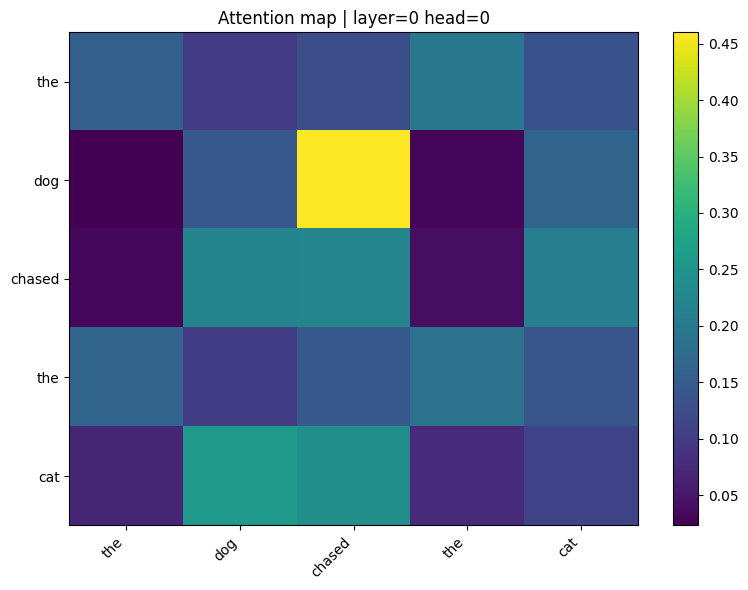

(['the', 'dog', 'chased', 'the', 'cat'],
 array([[0.15691003, 0.09967121, 0.128261  , 0.19768539, 0.13273123],
        [0.02312414, 0.14403634, 0.46008417, 0.030322  , 0.16377428],
        [0.03243107, 0.22033837, 0.22269075, 0.03860721, 0.20987207],
        [0.16604121, 0.10329498, 0.14475343, 0.18685679, 0.14052476],
        [0.07074468, 0.25980058, 0.23938757, 0.07658081, 0.11063784]],
       dtype=float32))

In [6]:
plot_attention(tokenizer, model, "The dog chased the cat")

La imagen es un mapa de atención para la oración: the dog chased the cat.

Es la atención que se aprende en la capa 0 y head 0.

- Filas → palabra que está “mirando”
- Columnas → palabras a las que presta atención
- Color más claro → más atención
- Color oscuro → poca atención

1) Fila dog: La celda más clara está en chased. ¿Qué significa? Dog presta mucha atención a chased. Esto tiene sentido porque dog es el sujeto y chased es el verbo.

**El modelo (en la head = 0) está capturando la relación sujeto → verbo.**

2) Fila cat: las celdas más claras están en dog y chased.
cat presta atención al verbo y al sujeto

Esto refleja la estructura: dog → chased → cat

3) Fila chased: el verbo presta atención a dog y a cat .
Esto es muy interesante porque el verbo necesita saber:
- quién hace la acción (dog = sujeto)
- sobre quién se realiza (cat = objeto)

4) Filas the: los determinantes suelen prestar atención al sustantivo que modifican. Aunque en esta cabeza concreta la señal no es tan fuerte.

Por tanto, esta cabeza de atención está capturando la estructura básica de la oración: dog (sujeto) → chased (verbo) → cat (objeto)



Veamos que captura esa head, para la oración **The cat chased the dog**.

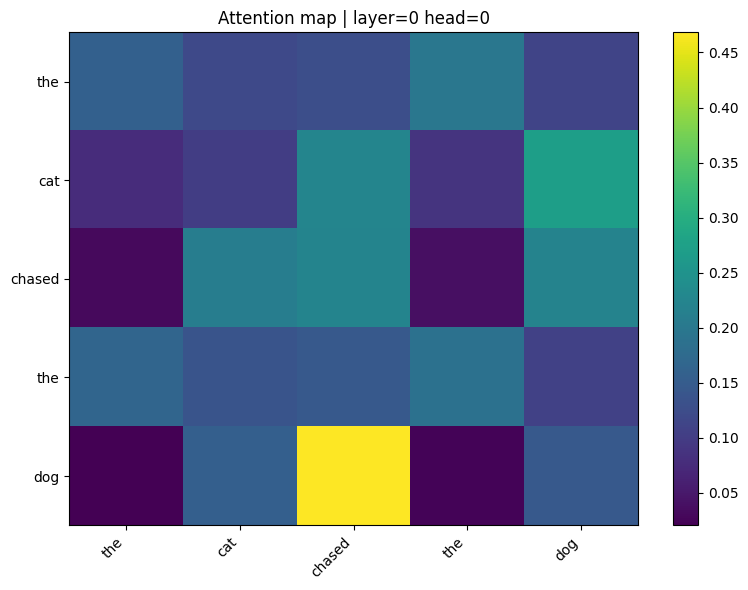

(['the', 'cat', 'chased', 'the', 'dog'],
 array([[0.15706809, 0.11972765, 0.12839021, 0.19788451, 0.11190163],
        [0.07707188, 0.10193853, 0.22468658, 0.08797445, 0.27140227],
        [0.032402  , 0.21034044, 0.22249109, 0.03857259, 0.2203808 ],
        [0.1660197 , 0.13751166, 0.14473468, 0.18683258, 0.10640605],
        [0.02056326, 0.15680157, 0.46825638, 0.02548018, 0.14522085]],
       dtype=float32))

In [7]:
# 6) Más ejemplos
plot_attention(tokenizer, model, "The cat chased the dog", layer=0, head=0)


- dog → chased (muy fuerte). Esta head está capturando la relación objeto–verbo.
- cat → chased. Reflejando la relación sujeto–verbo.
- chased → cat y dog. El verbo presta atención a ambos sustantivos, porque son sus argumentos (quién realiza la acción y sobre quién).

Nuevamente, podemos comprobar que esta cabeza de atención está capturando la estructura básica de la oración: cat (sujeto) → chased (verbo) → dog (objeto)


Vamos a ver qué relaciones captura en la siguiente oración

Vamos a estudiar qué relaciones captura en esta otra  oración:

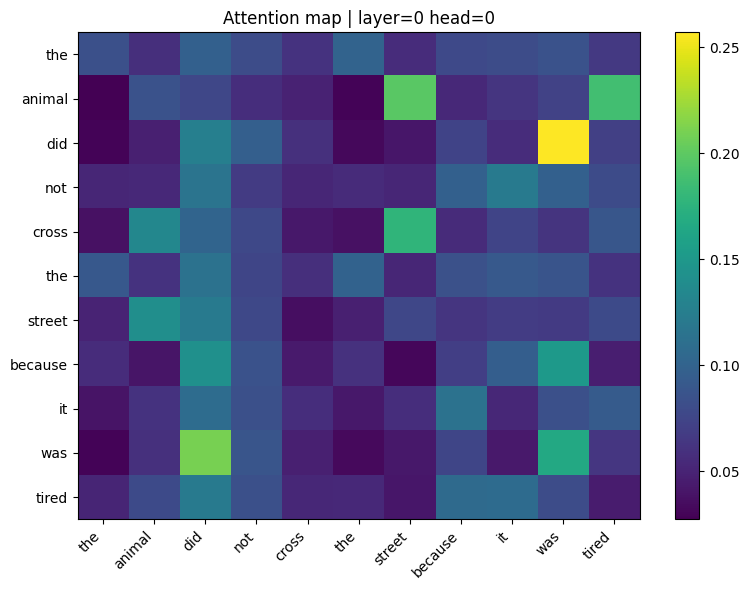

(['the',
  'animal',
  'did',
  'not',
  'cross',
  'the',
  'street',
  'because',
  'it',
  'was',
  'tired'],
 array([[0.08353912, 0.0585122 , 0.09732147, 0.0803802 , 0.06058097,
         0.09998812, 0.05681054, 0.07814762, 0.08070548, 0.08543412,
         0.06538359],
        [0.02723891, 0.0850483 , 0.07583721, 0.05719604, 0.04879227,
         0.02940208, 0.19860834, 0.05350449, 0.06270432, 0.07239363,
         0.18708141],
        [0.029379  , 0.04763485, 0.12676129, 0.09688331, 0.05926542,
         0.03198665, 0.0408724 , 0.07325589, 0.05680379, 0.2570564 ,
         0.0712059 ],
        [0.05164847, 0.05340674, 0.11521646, 0.0670367 , 0.05148908,
         0.05508753, 0.0518119 , 0.09732258, 0.12180834, 0.09765854,
         0.07942303],
        [0.03798751, 0.13318971, 0.1013706 , 0.07686341, 0.04204316,
         0.03757492, 0.17721248, 0.05572886, 0.07477965, 0.06182998,
         0.08903788],
        [0.09084851, 0.06107103, 0.11343667, 0.0749888 , 0.05864683,
         0.0991116

In [16]:
plot_attention(tokenizer, model, "The animal did not cross the street because it was tired", layer=0, head=0)

- animal → street (fuerte). El modelo relaciona animal con street, probablemente capturando la acción cross the street.
- Los auxiliares (did, was) prestan atención al verbo principal o a otras partes de la estructura verbal.
- cross → street. El verbo cross presta atención a street, reflejando la relación verbo–objeto.

- it → street y was. En esta cabeza, it parece atender más a street que a animal, lo que muestra que una sola cabeza no siempre resuelve bien la coreferencia.


Por tanto, la primera cabeza de atención de este modelo parece capturar sobre todo relaciones verbo–objeto y estructura verbal, pero no resuelve claramente la referencia de “it”. Otras capas o cabezas del modelo suelen hacerlo mejor.

En BERT, las relaciones de coreferencia (como “it” → “animal”) suelen aparecer en capas intermedias o altas, no en las primeras. La capa 0 que estás usando normalmente captura cosas más locales (determinantes, vecinos, estructura superficial).

| capas | tipo de información                         |
| ----- | ------------------------------------------- |
| 0–3   | relaciones locales (determinantes, vecinos) |
| 4–7   | sintaxis (sujeto–verbo, verbo–objeto)       |
| 8–11  | relaciones semánticas y coreferencia        |


Sin embargo, si probamos con la capa 9 y la head 1, esta head si es capaz de capturar la relación de correferencia (it-animal).

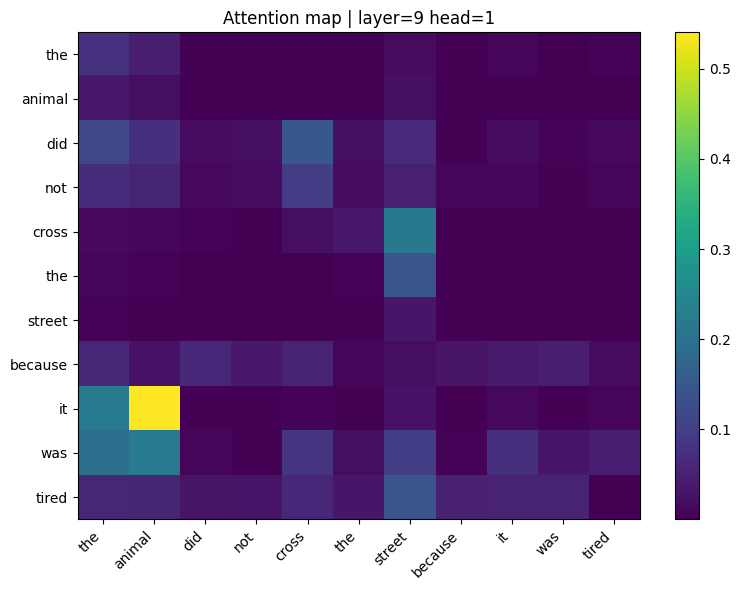

(['the',
  'animal',
  'did',
  'not',
  'cross',
  'the',
  'street',
  'because',
  'it',
  'was',
  'tired'],
 array([[7.6770745e-02, 4.6332296e-02, 3.2382363e-03, 4.3887105e-03,
         3.8816961e-03, 2.8372866e-03, 1.6042298e-02, 1.1057175e-03,
         7.0490967e-03, 1.9525880e-03, 5.3638876e-03],
        [3.4553908e-02, 2.0169524e-02, 3.0968075e-03, 3.4951351e-03,
         2.1239589e-03, 3.9283875e-03, 2.3008578e-02, 1.3823138e-03,
         3.9455141e-03, 1.3523693e-03, 2.0803665e-03],
        [1.1816062e-01, 7.2911203e-02, 1.6393689e-02, 1.9789141e-02,
         1.4714147e-01, 2.1204157e-02, 6.6945598e-02, 3.1407995e-03,
         1.8557908e-02, 6.5235649e-03, 1.1734833e-02],
        [7.0457108e-02, 5.6333970e-02, 1.2060658e-02, 1.7455852e-02,
         9.7971886e-02, 1.9161362e-02, 4.8450045e-02, 8.3349692e-03,
         9.2491703e-03, 4.2568888e-03, 1.0656395e-02],
        [1.4127721e-02, 8.1593180e-03, 4.7072982e-03, 2.0053952e-03,
         2.0200785e-02, 3.4617789e-02, 2.19176

In [18]:
plot_attention(
    tokenizer,
    model,
    "The animal did not cross the street because it was tired",
    layer=9,
    head=1
)

El siguiente  código te permite obtener los attention map para distintas capas y heads:

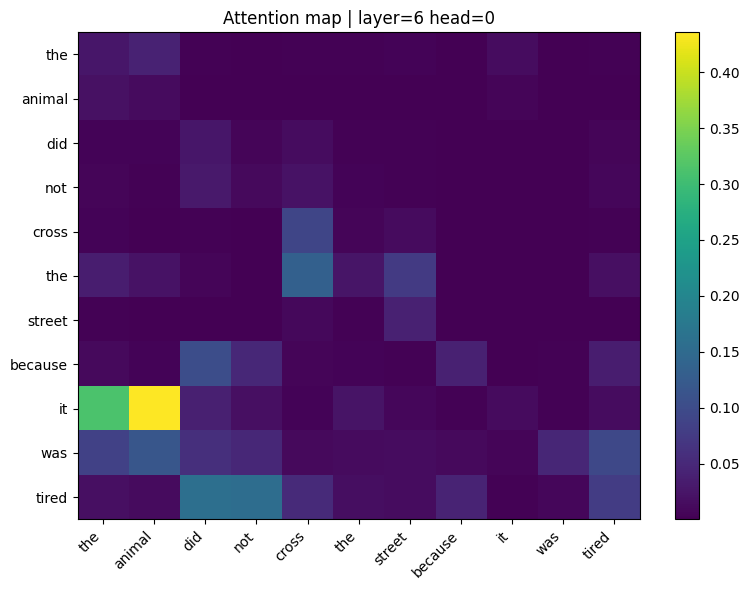

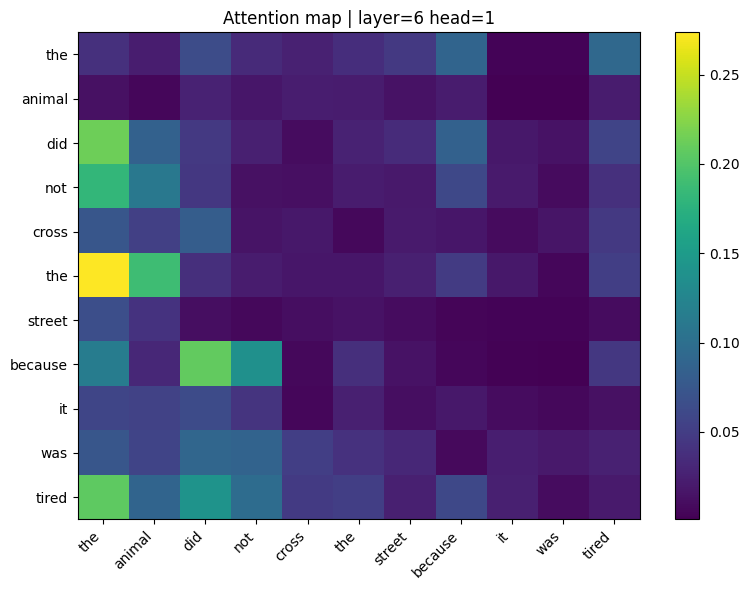

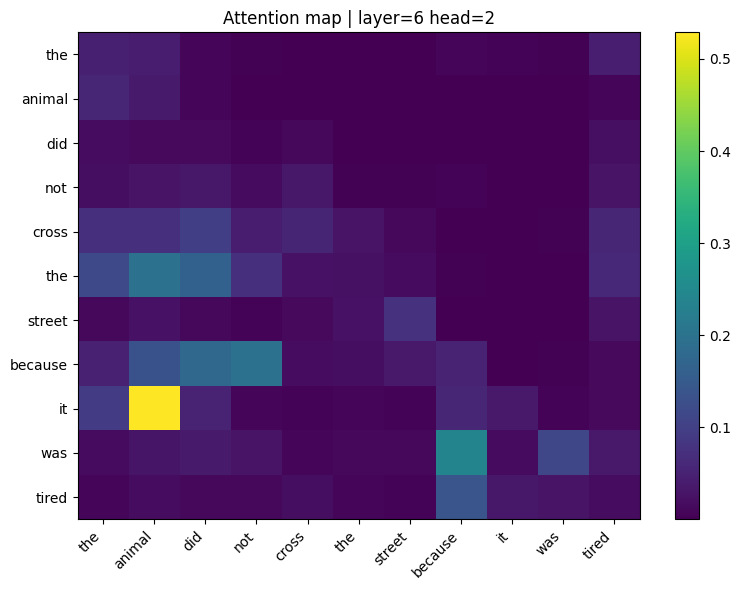

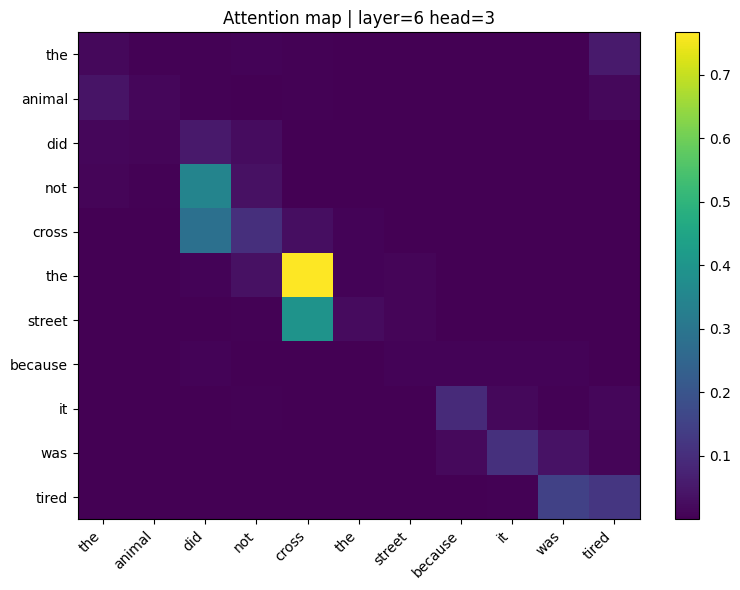

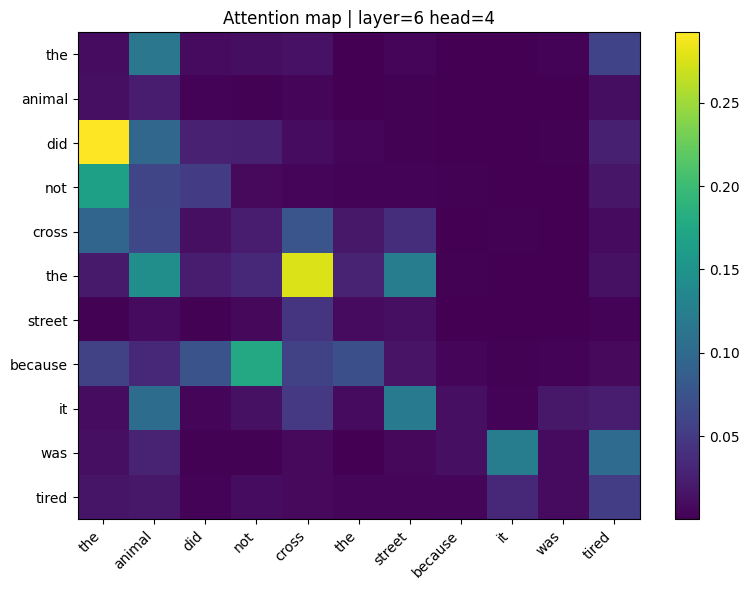

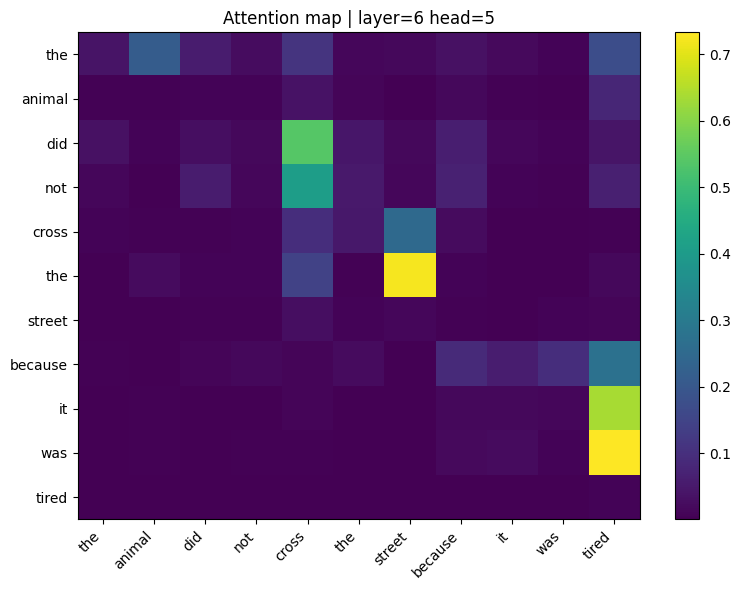

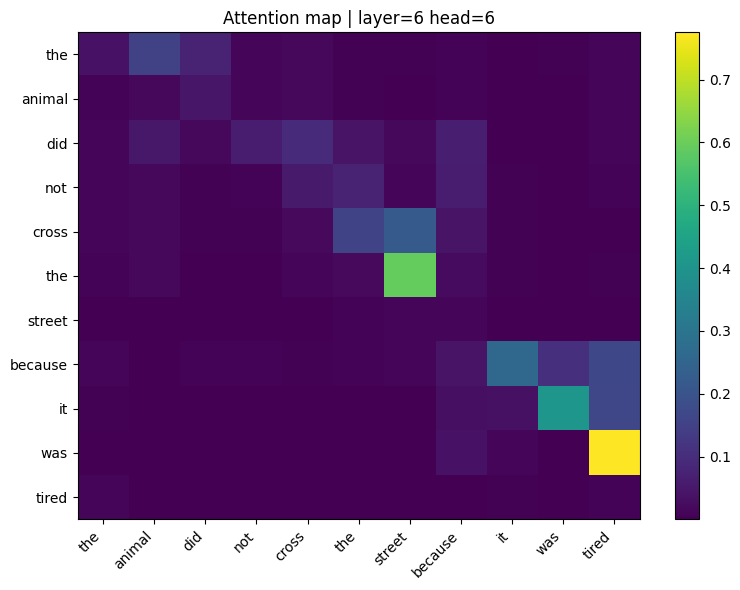

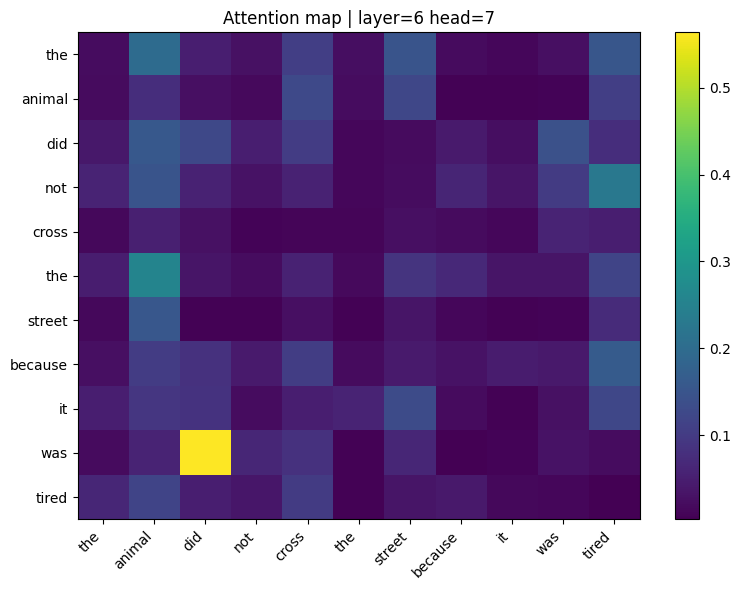

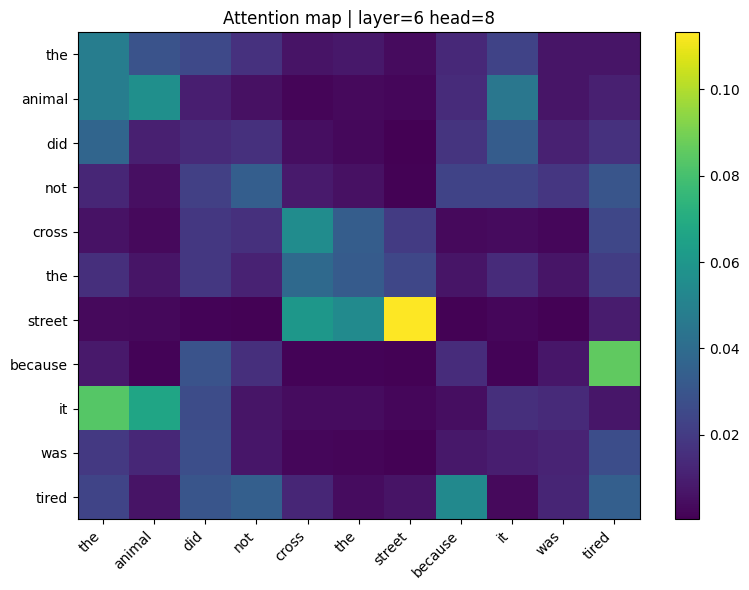

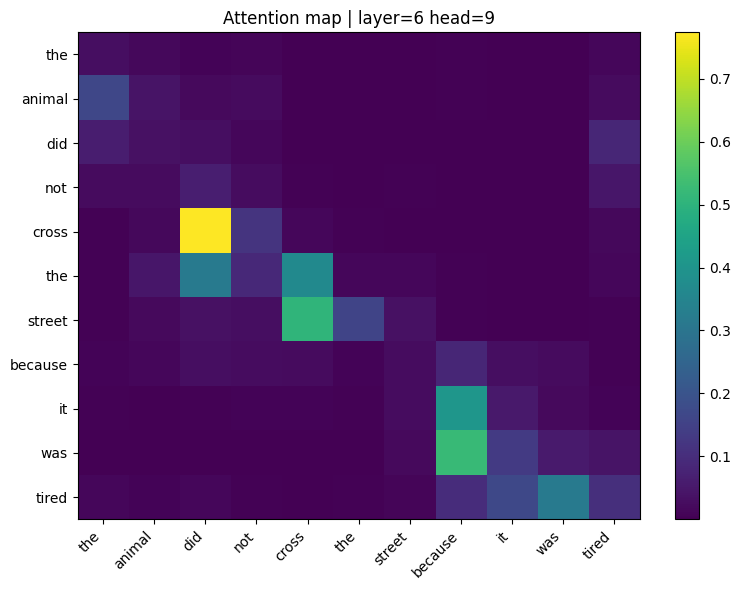

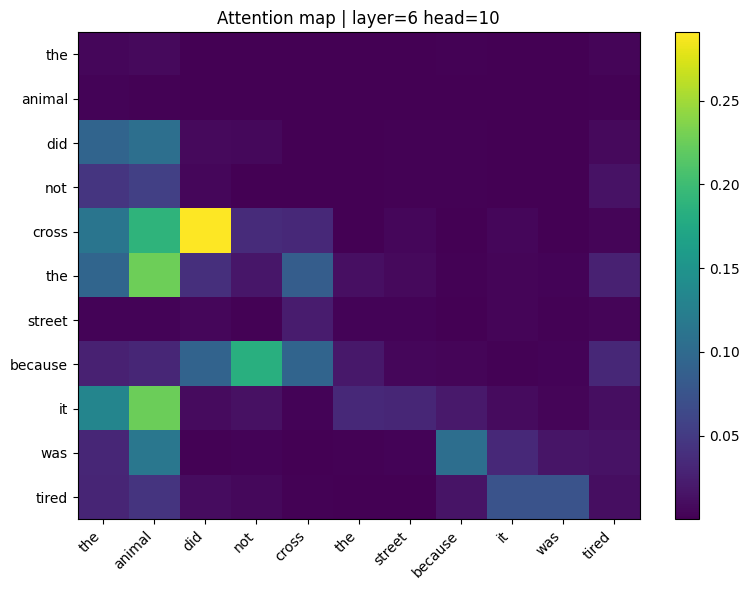

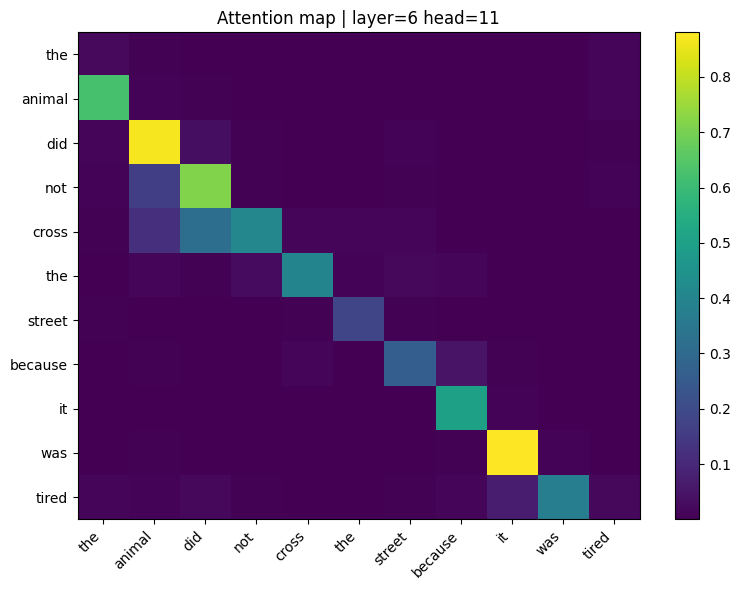

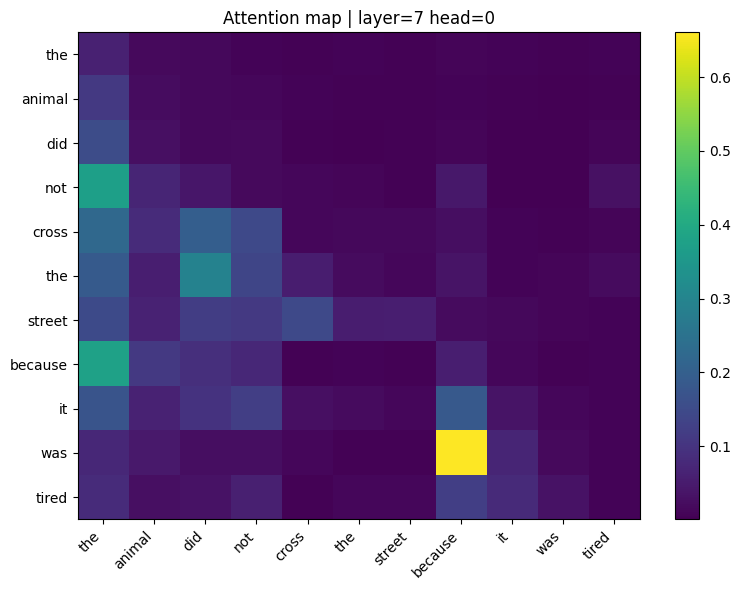

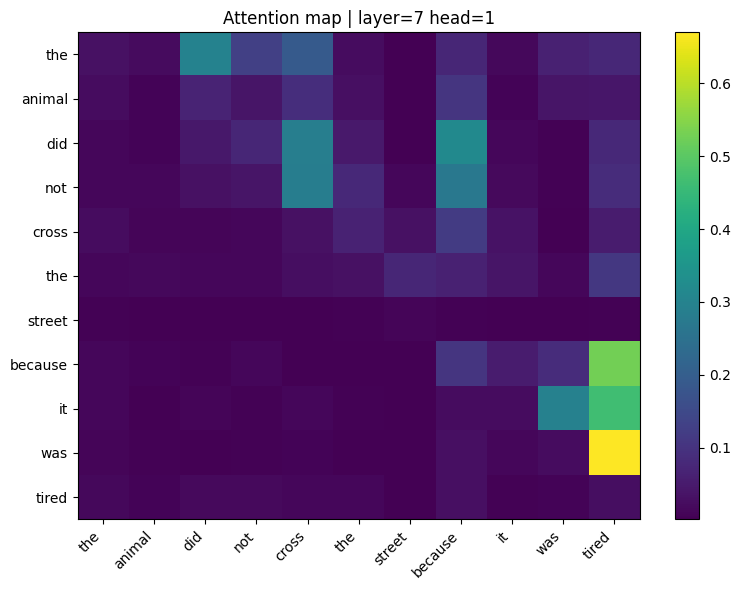

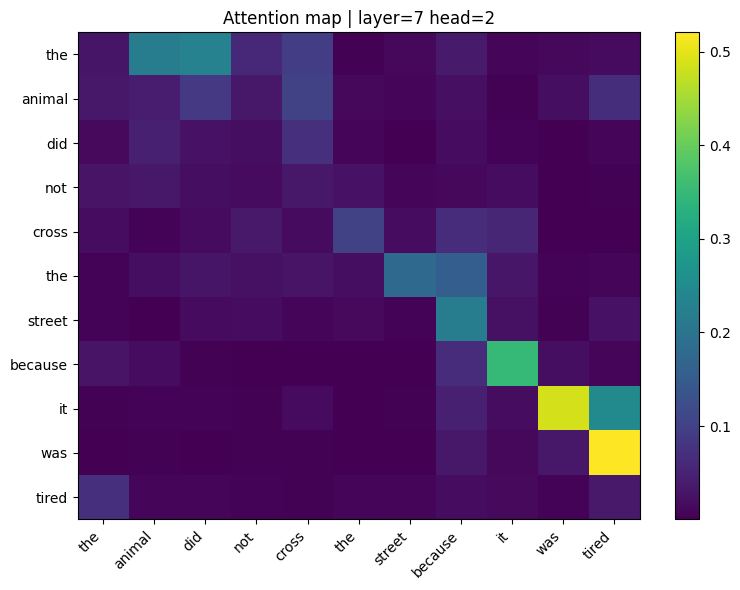

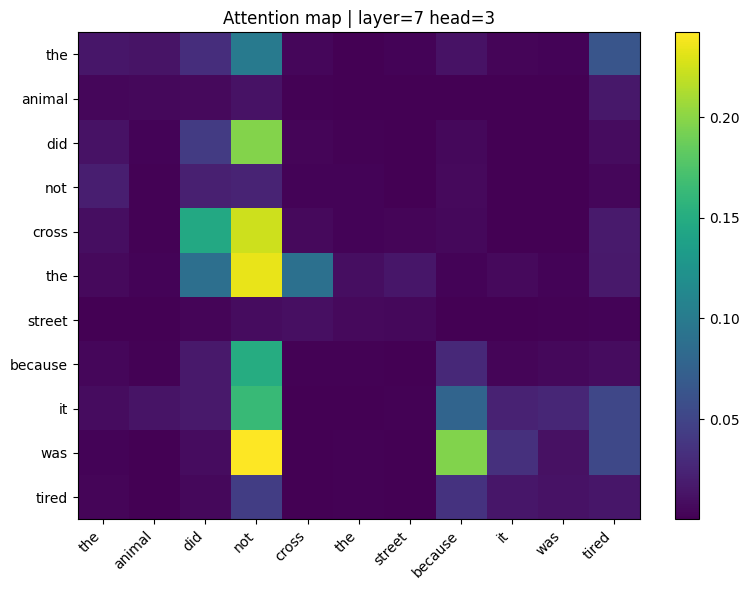

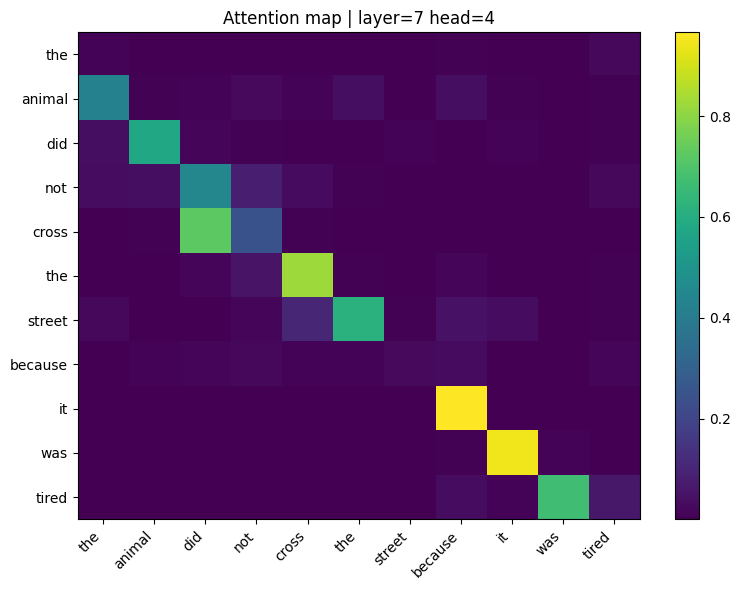

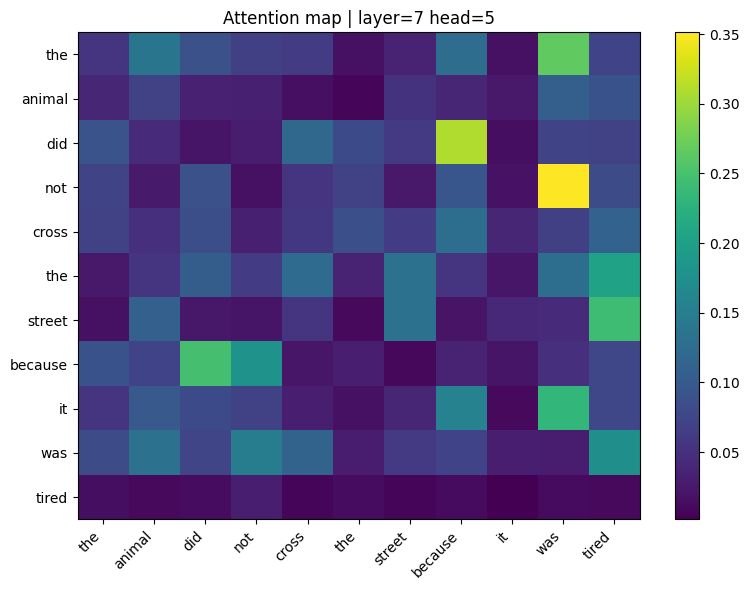

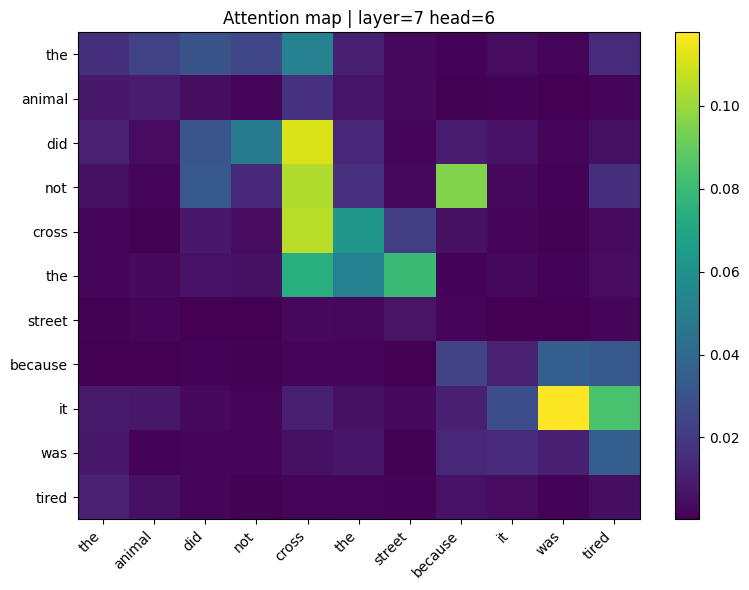

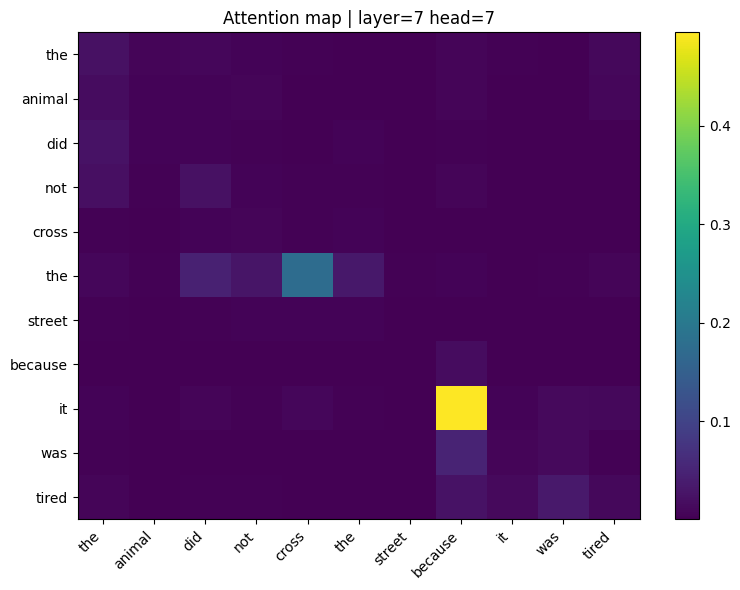

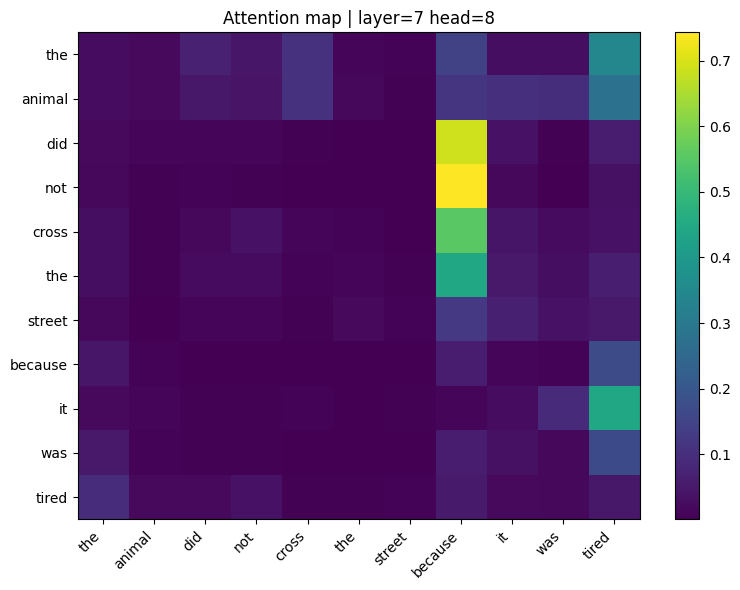

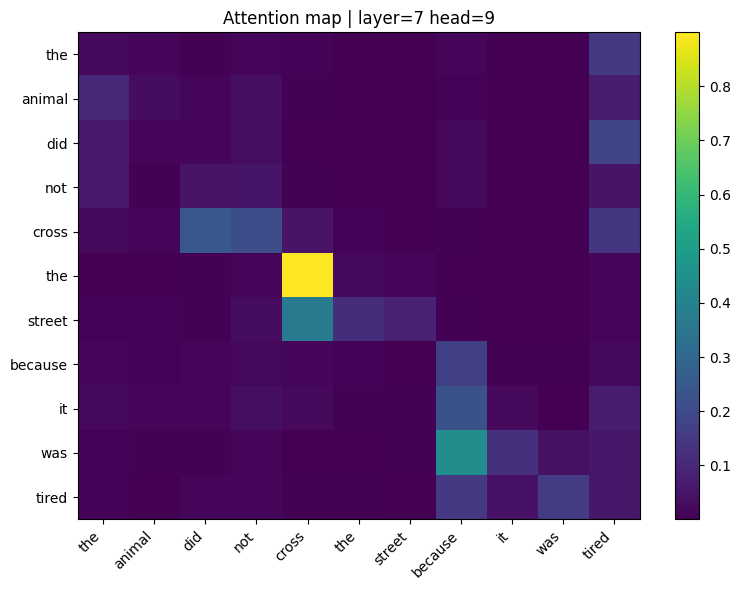

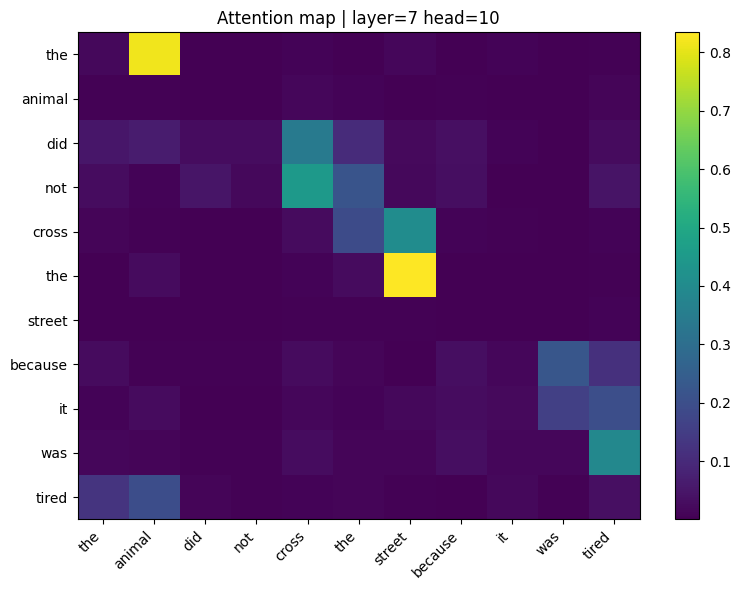

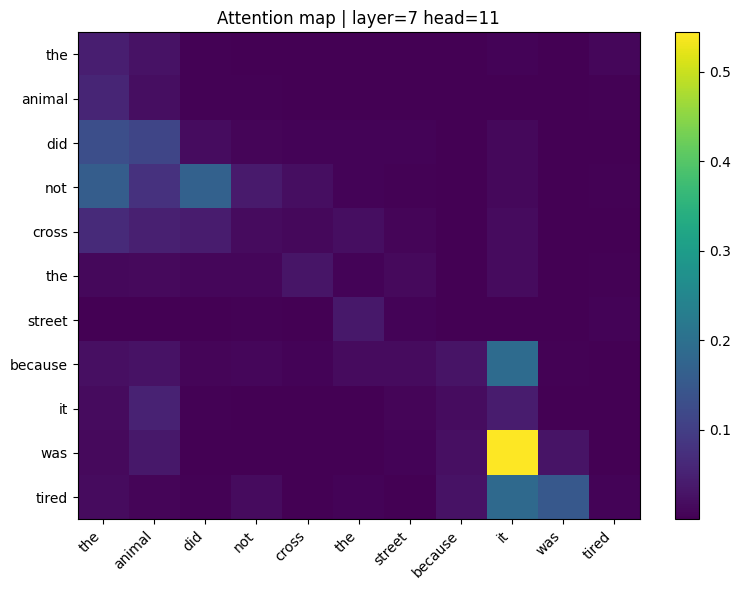

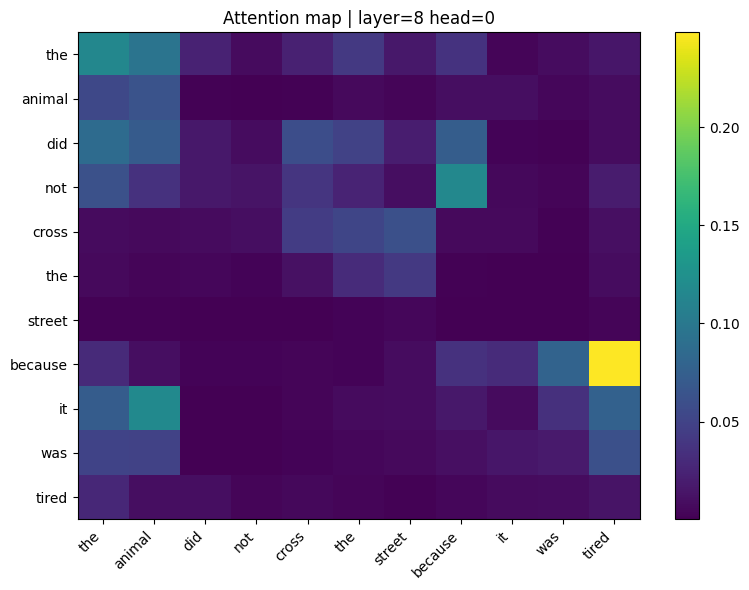

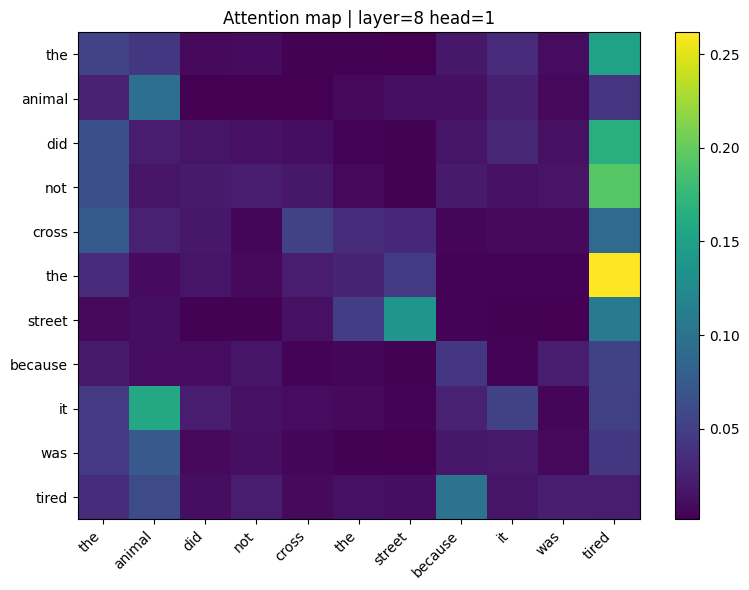

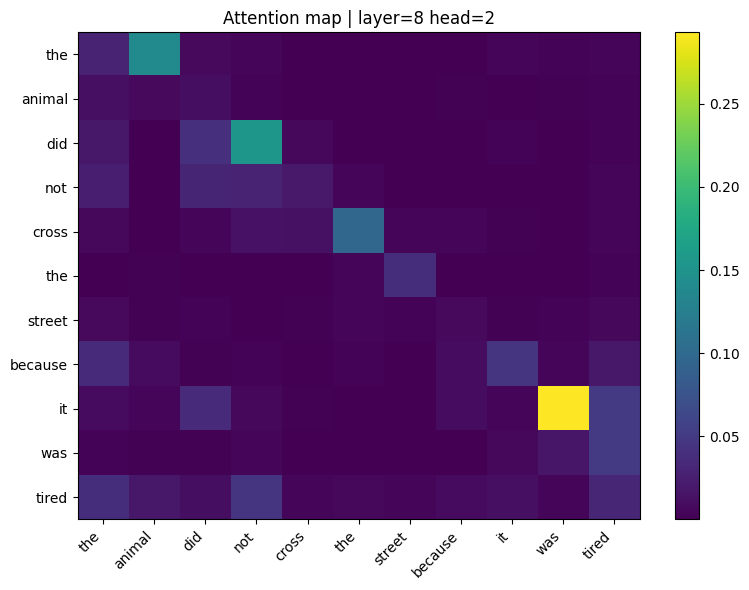

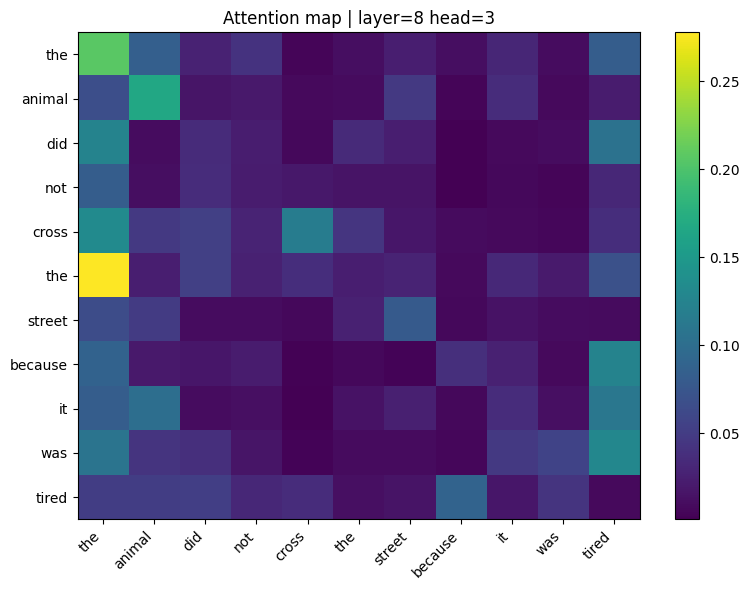

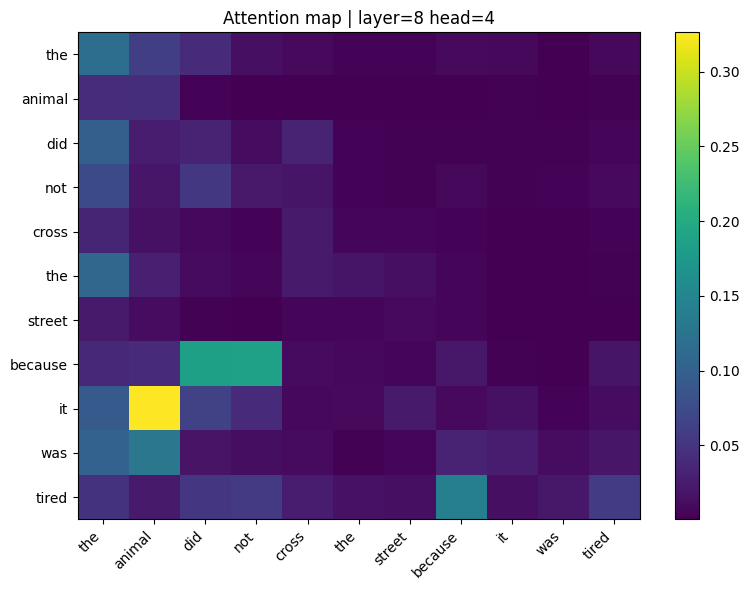

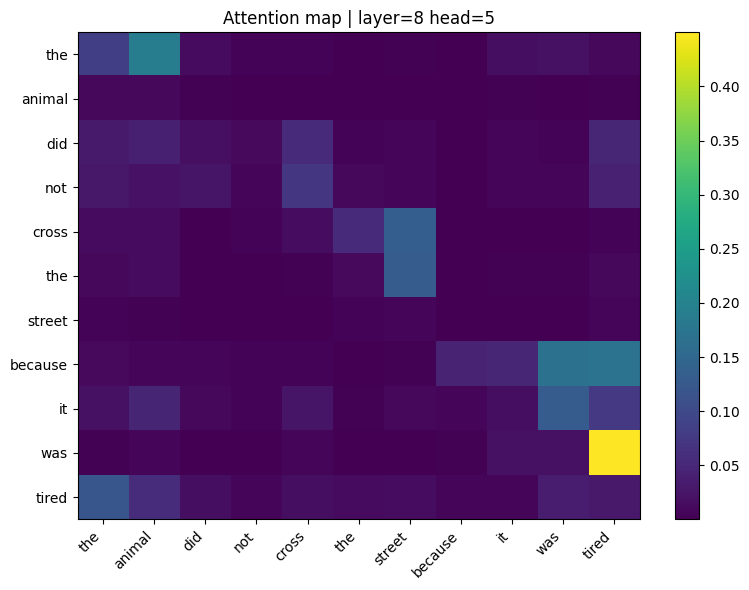

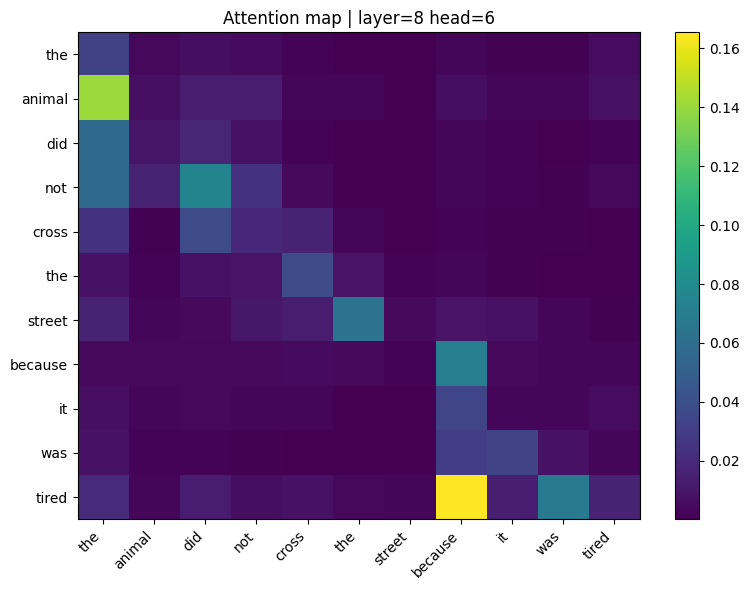

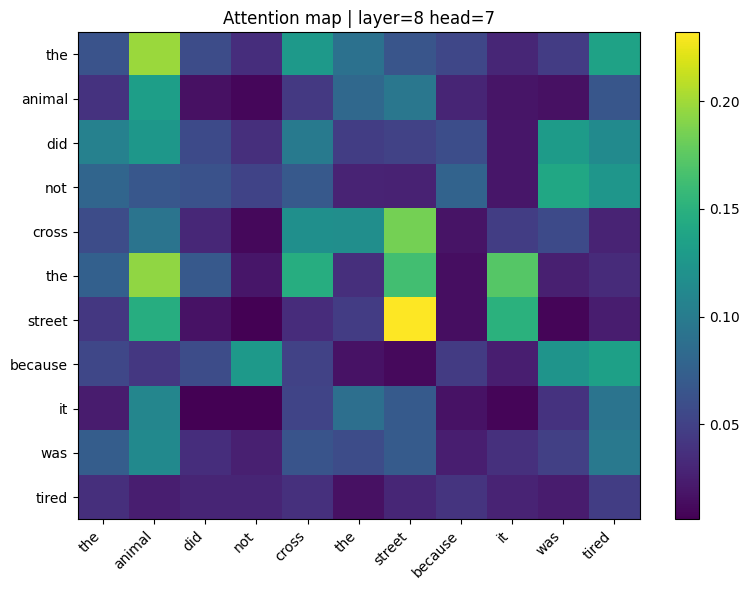

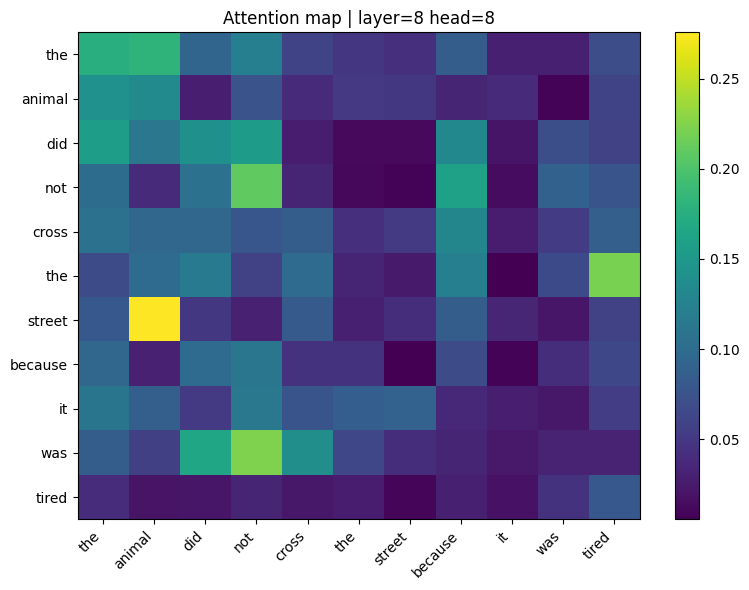

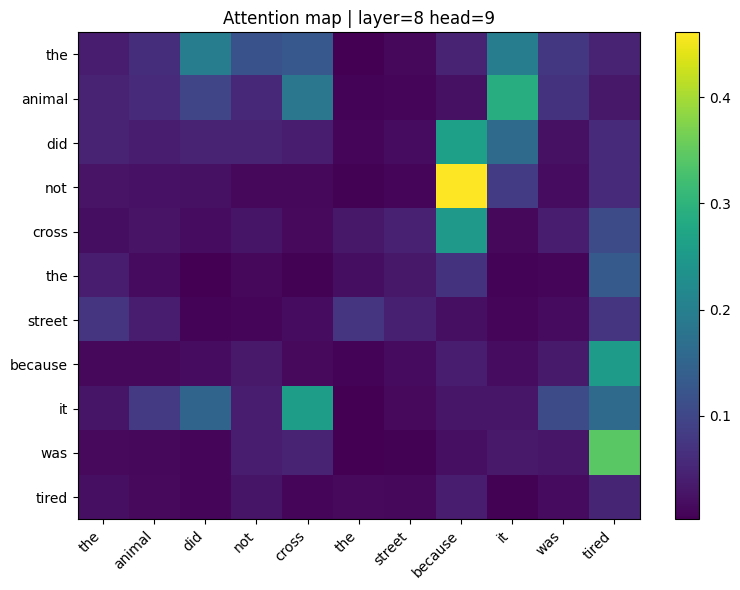

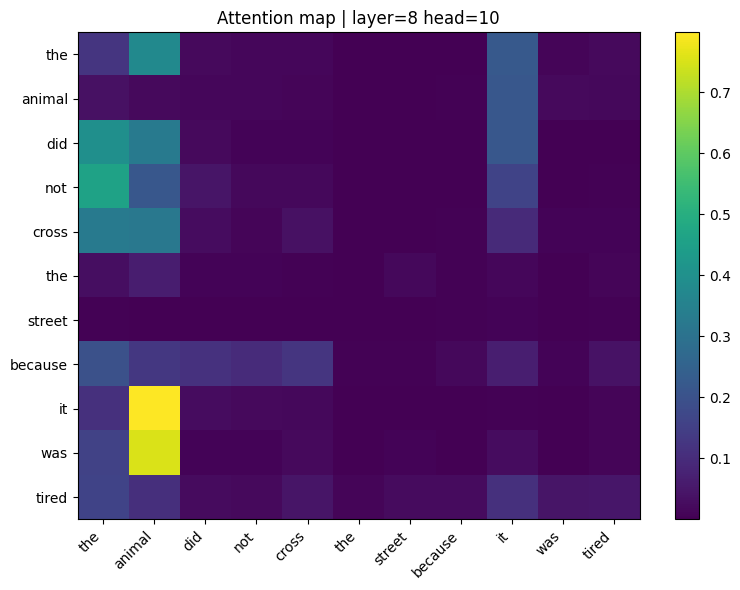

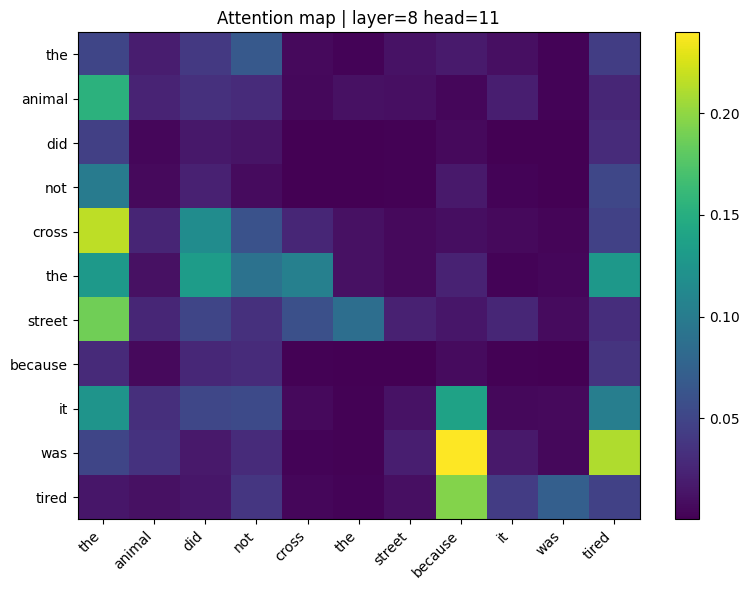

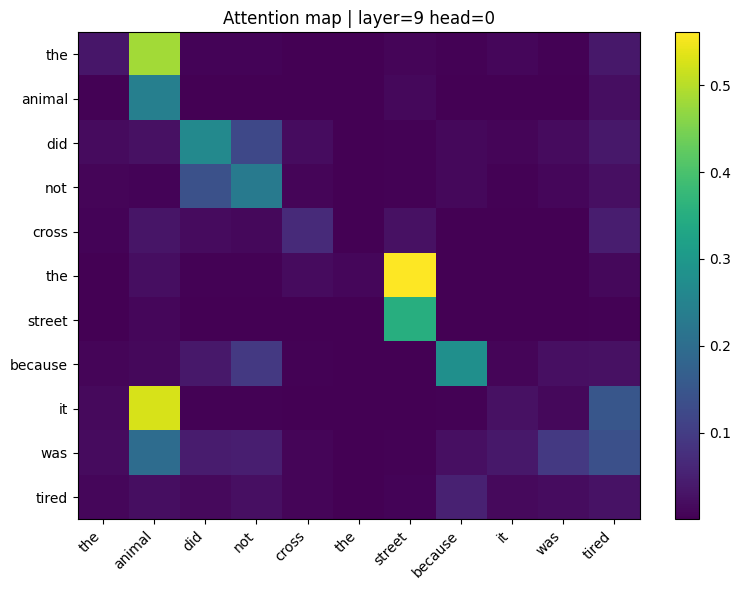

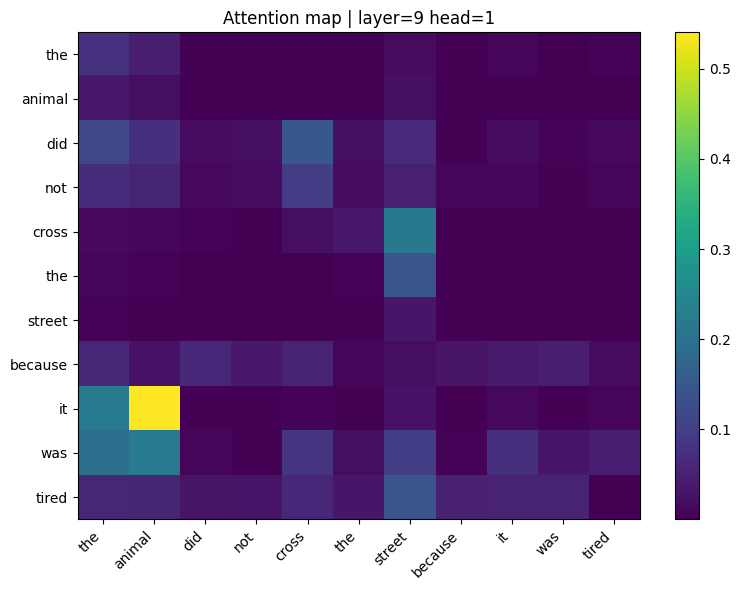

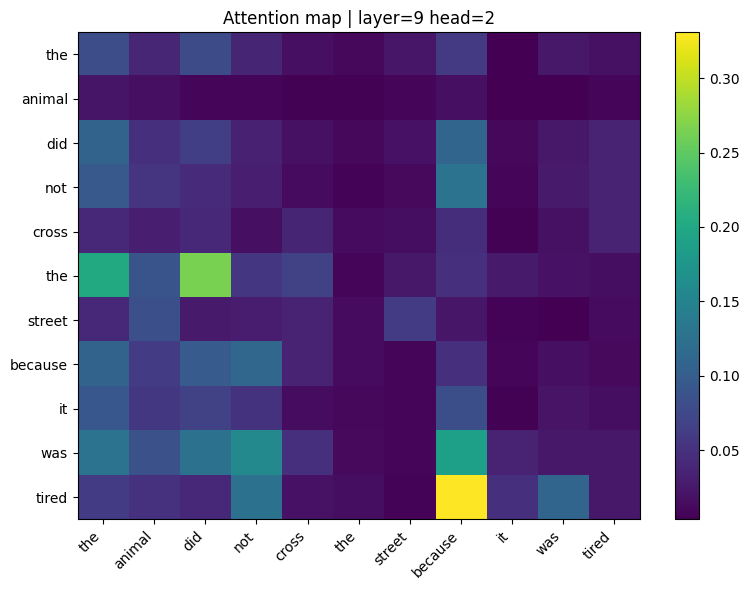

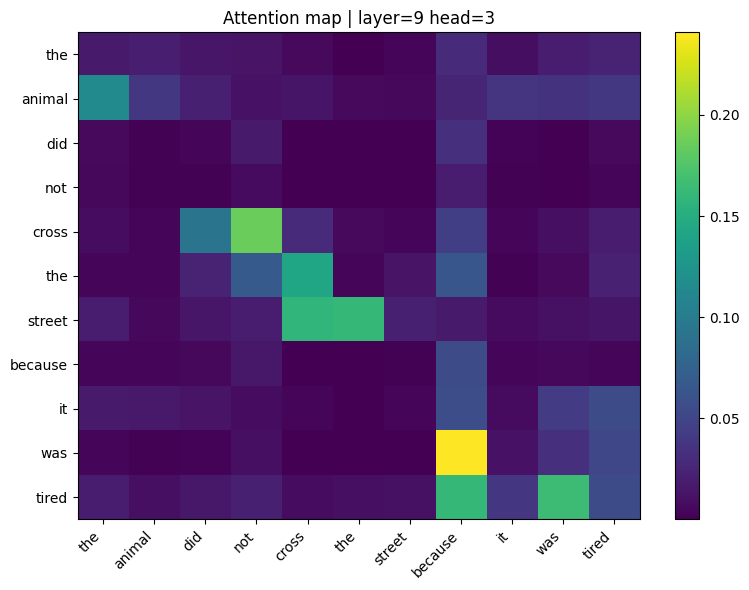

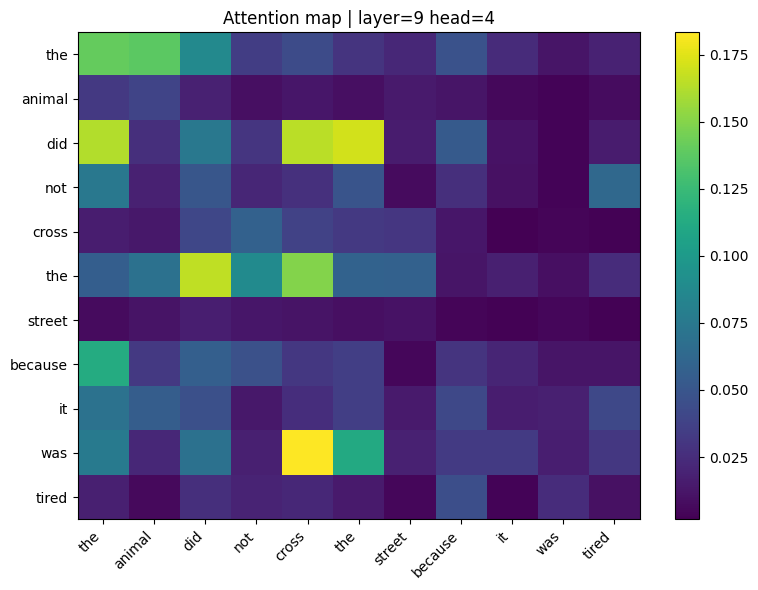

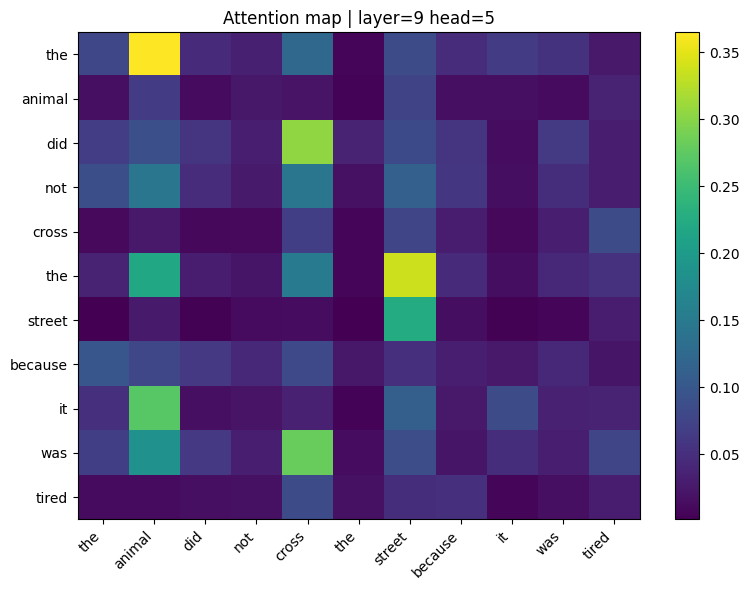

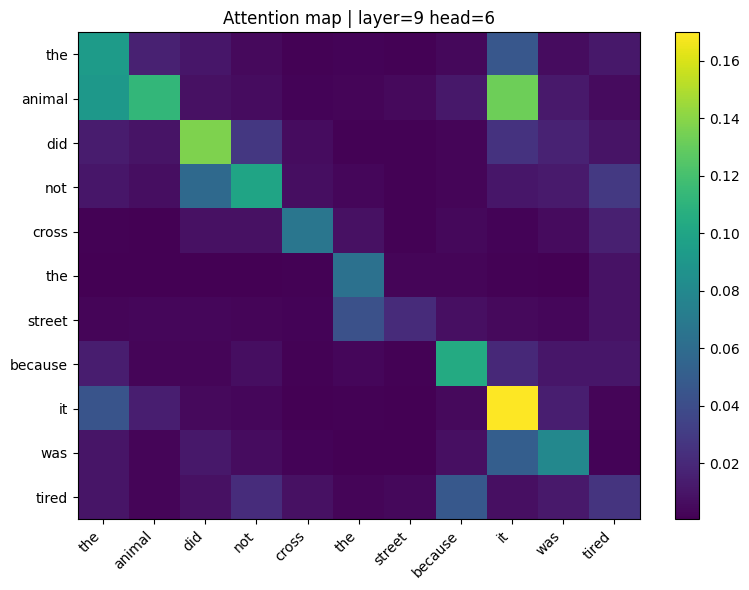

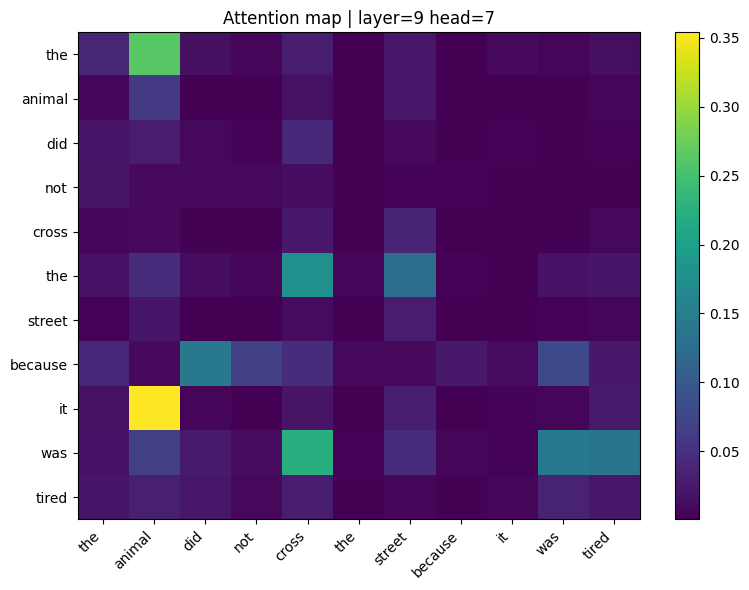

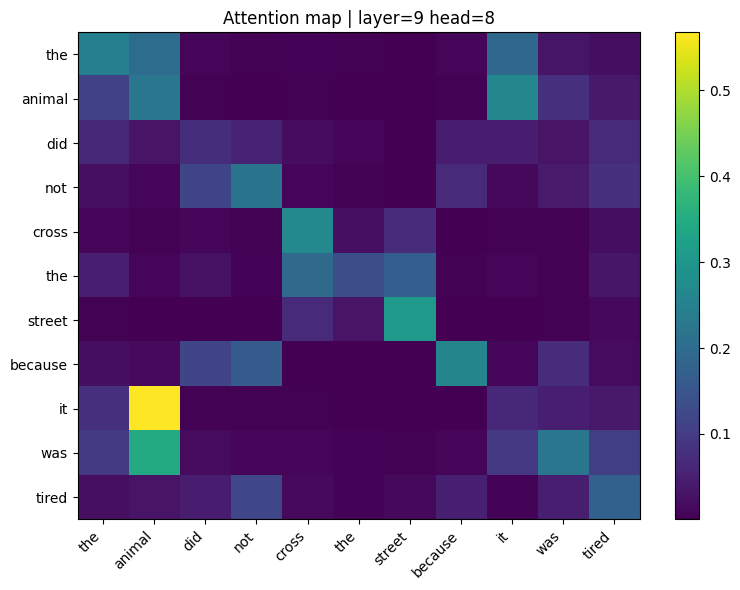

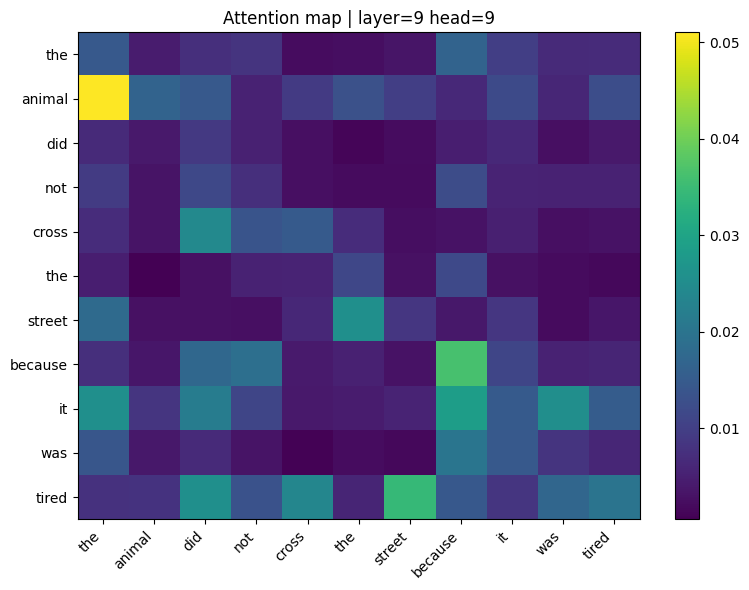

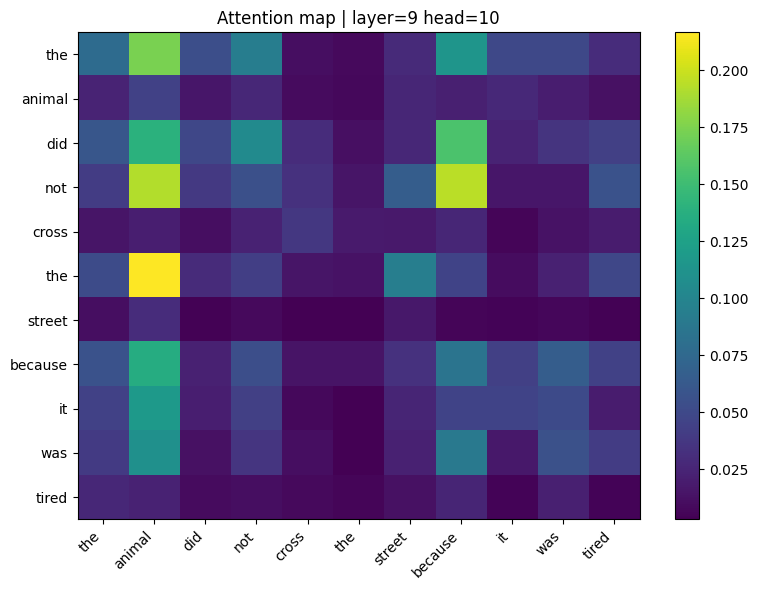

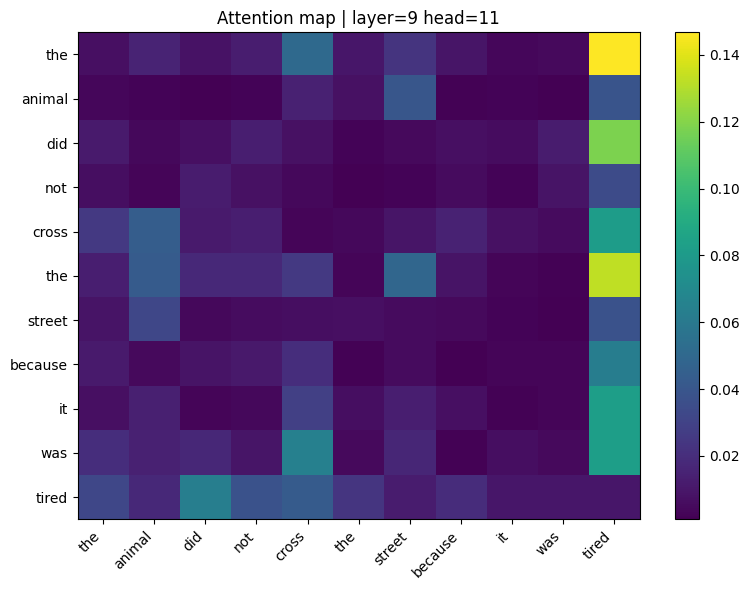

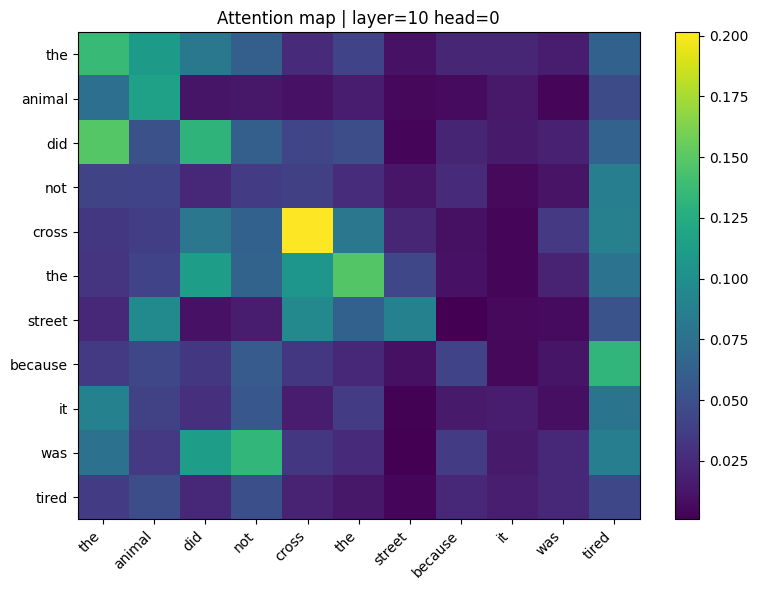

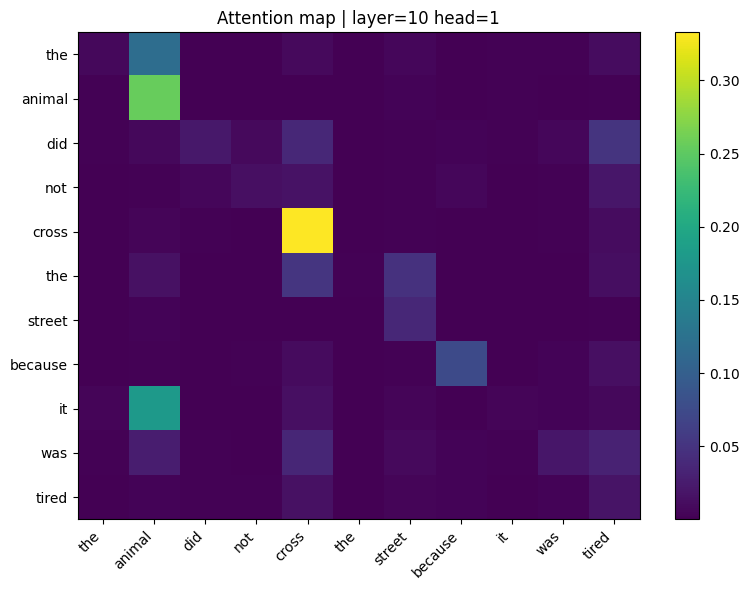

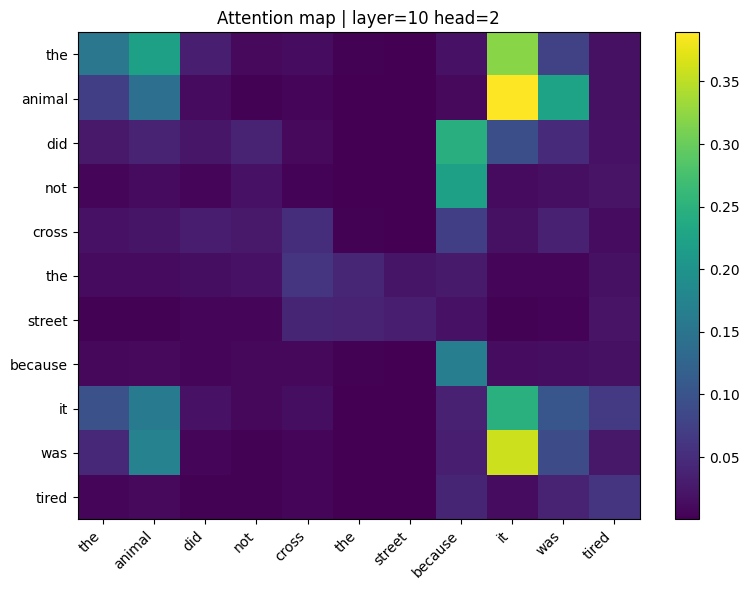

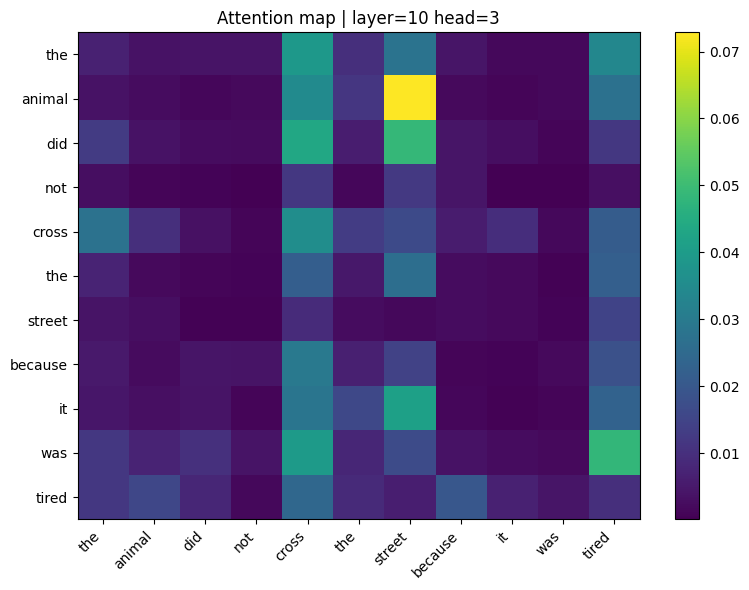

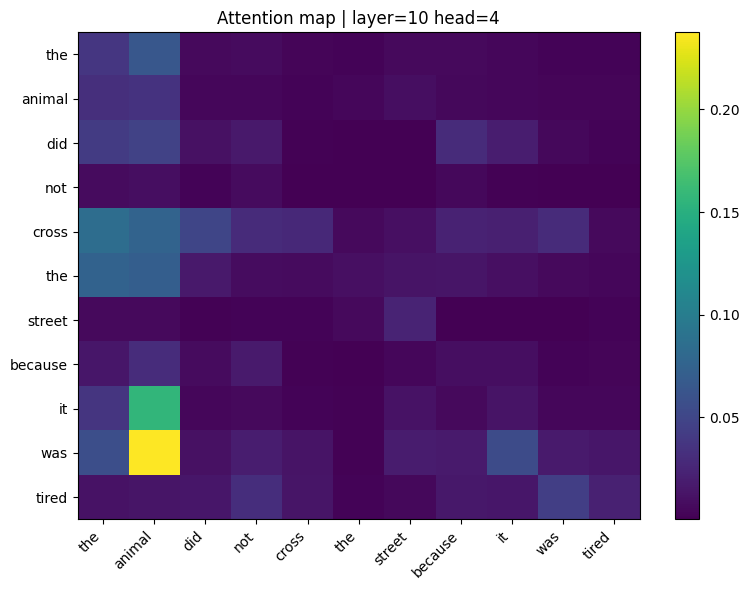

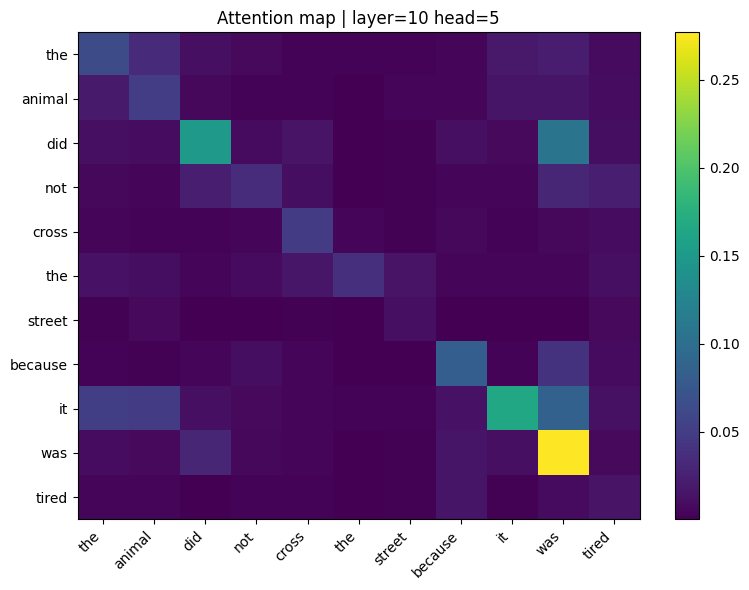

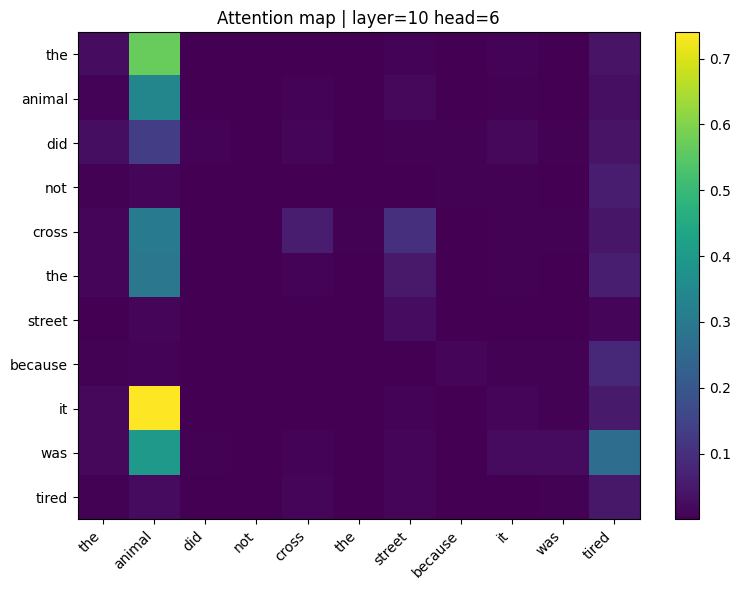

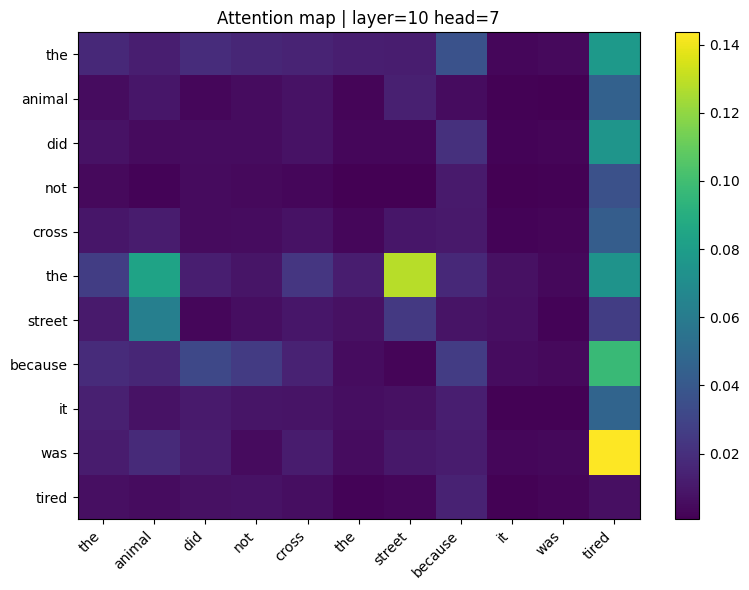

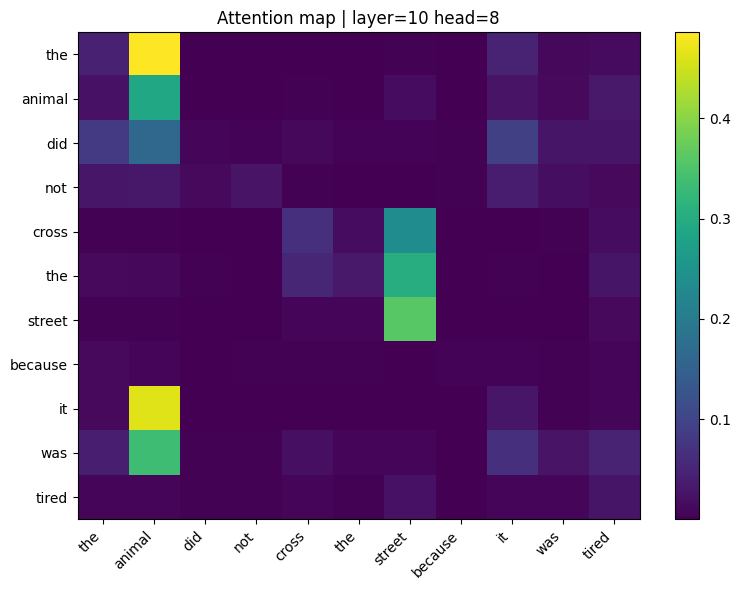

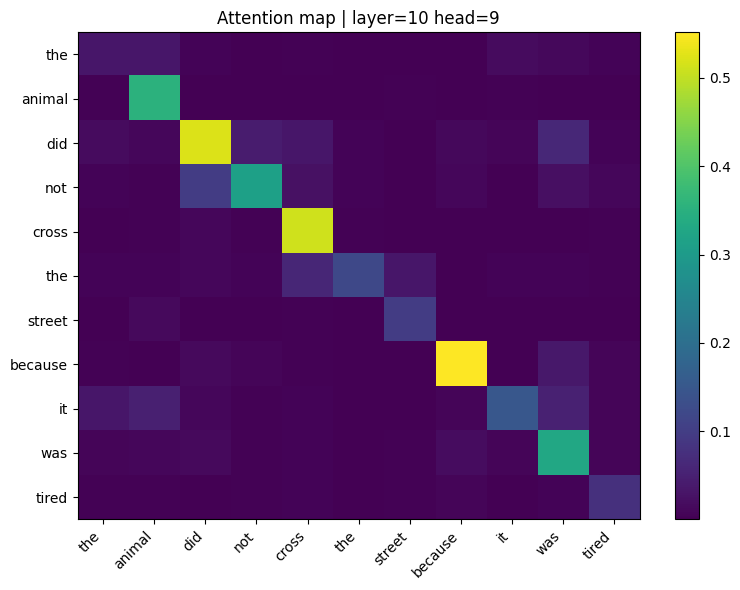

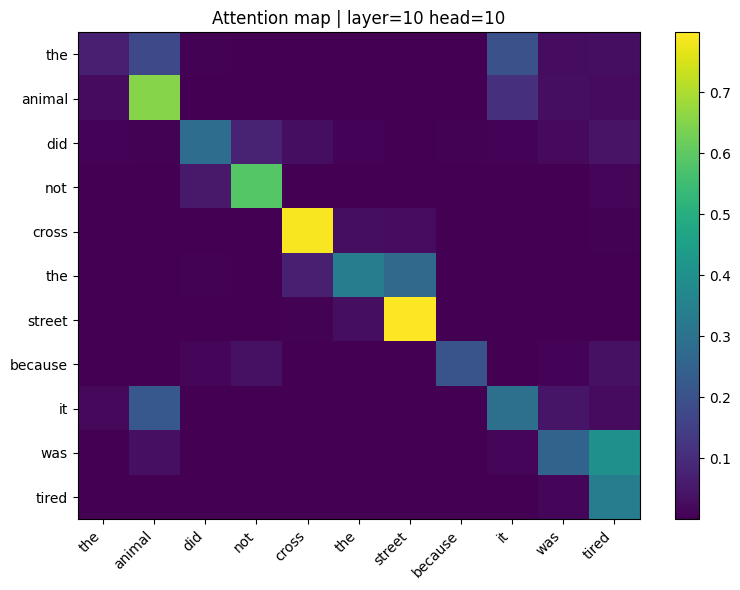

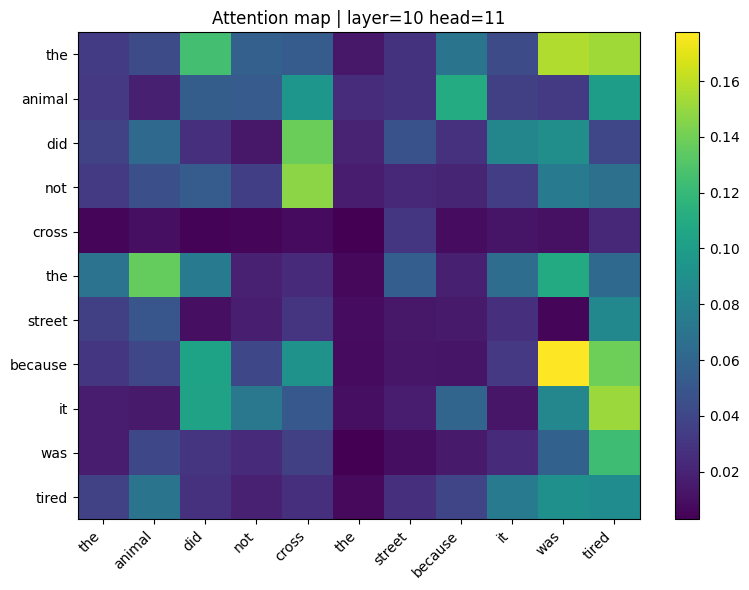

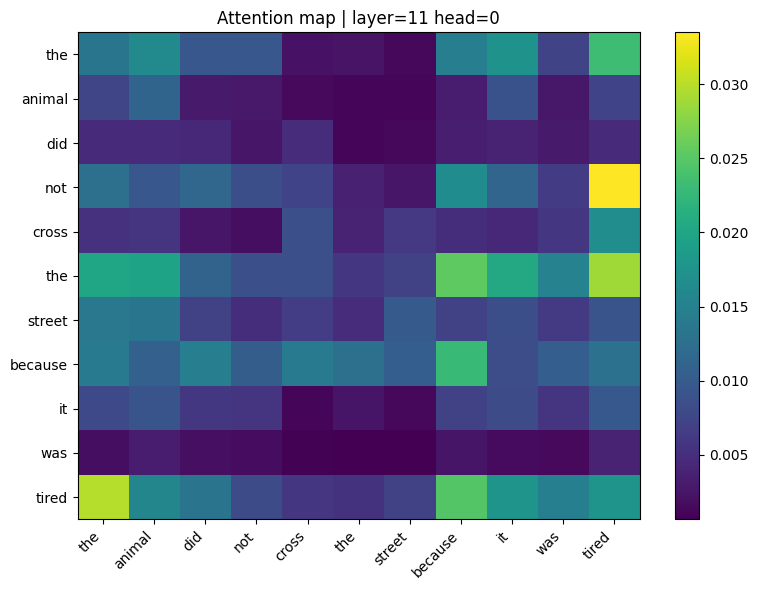

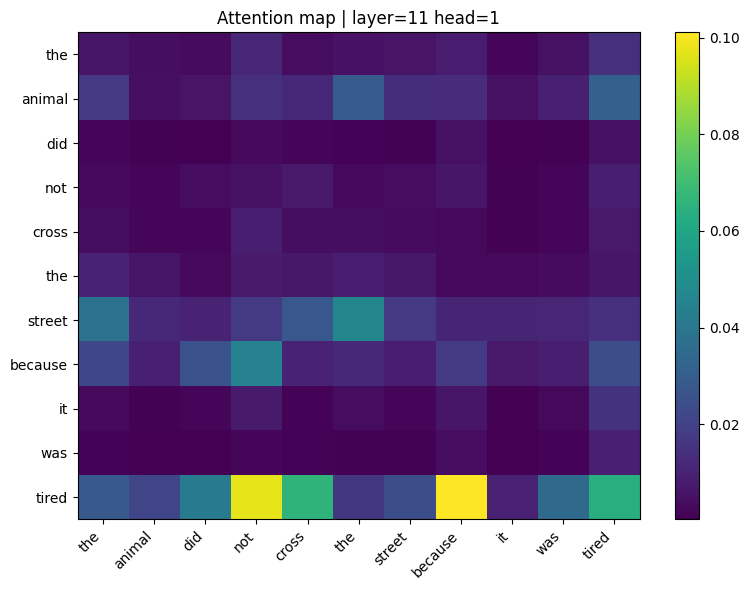

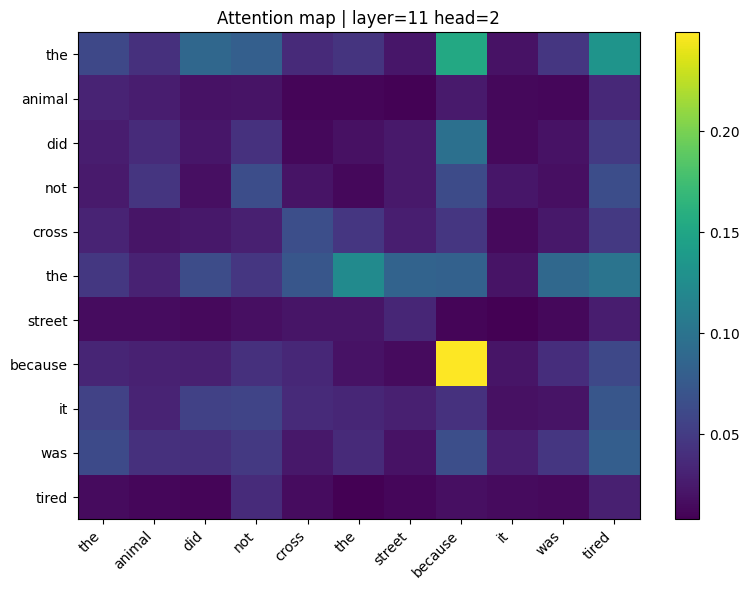

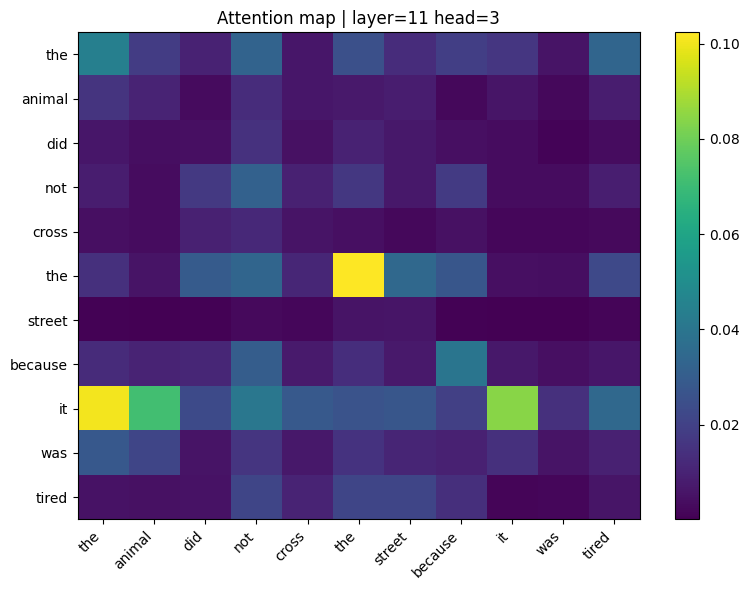

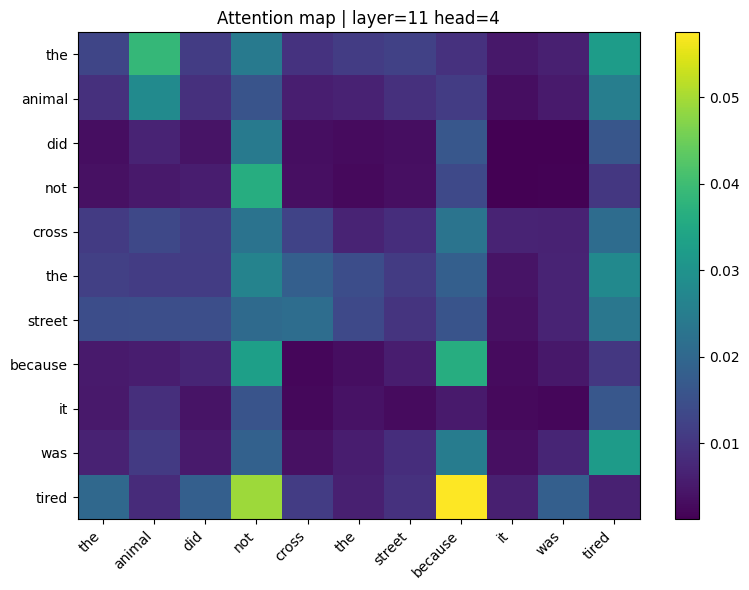

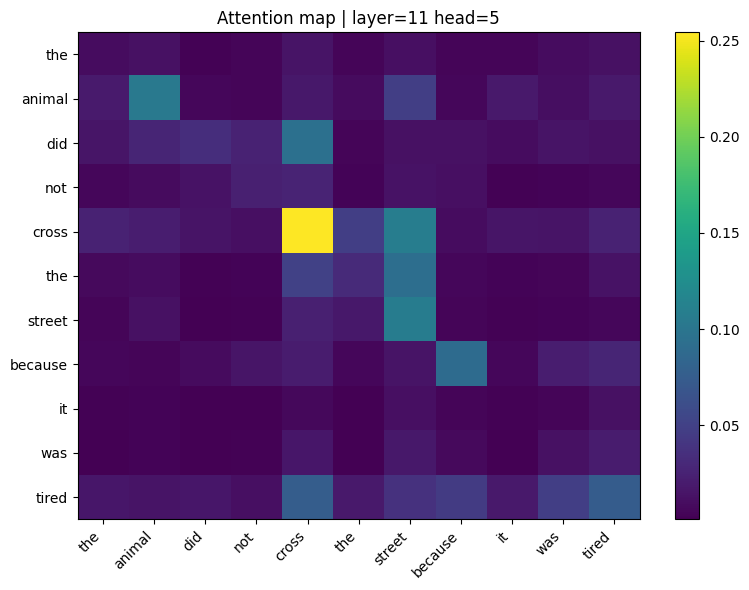

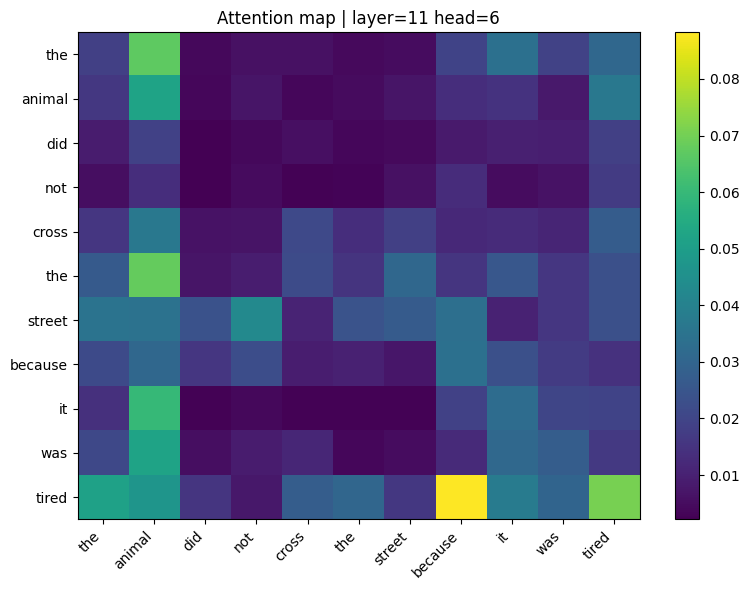

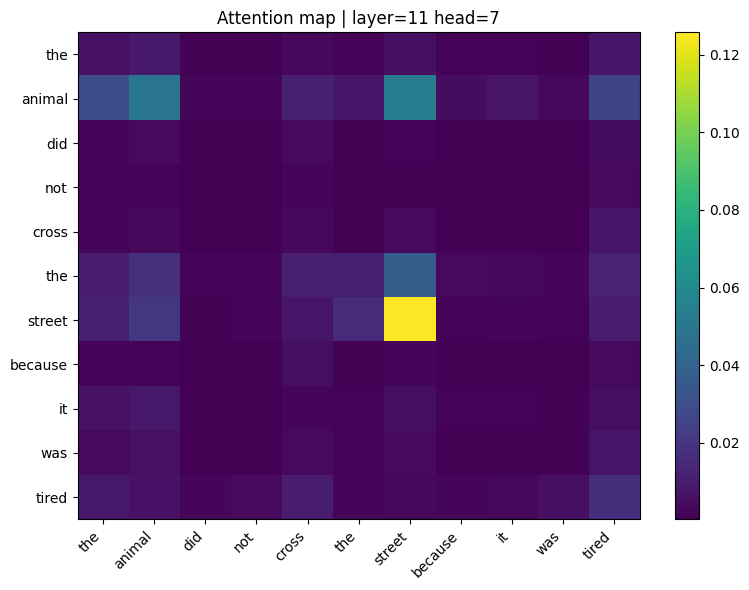

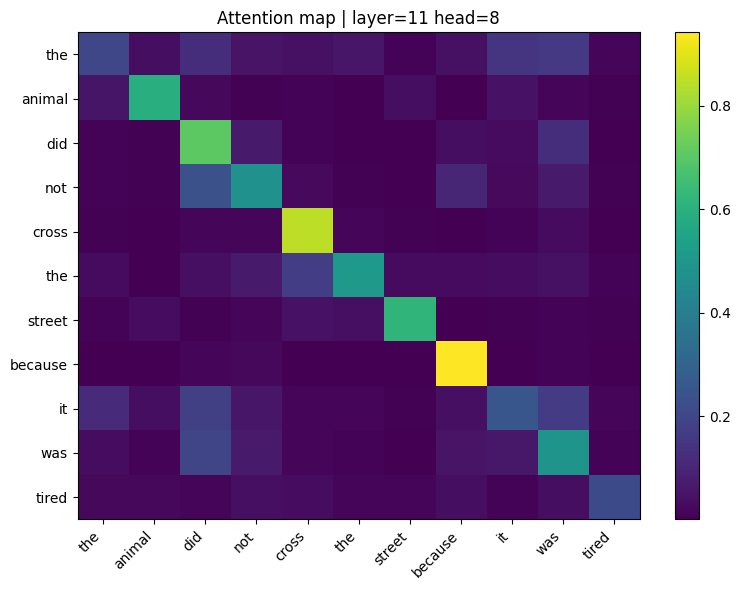

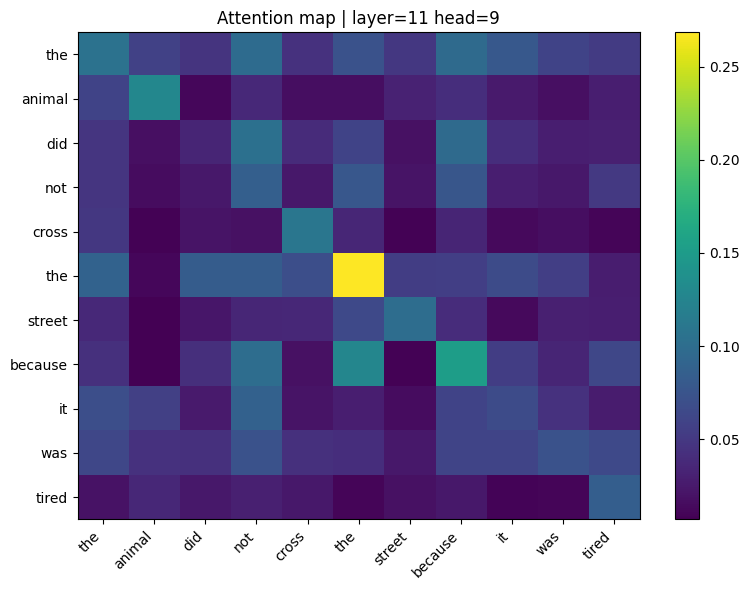

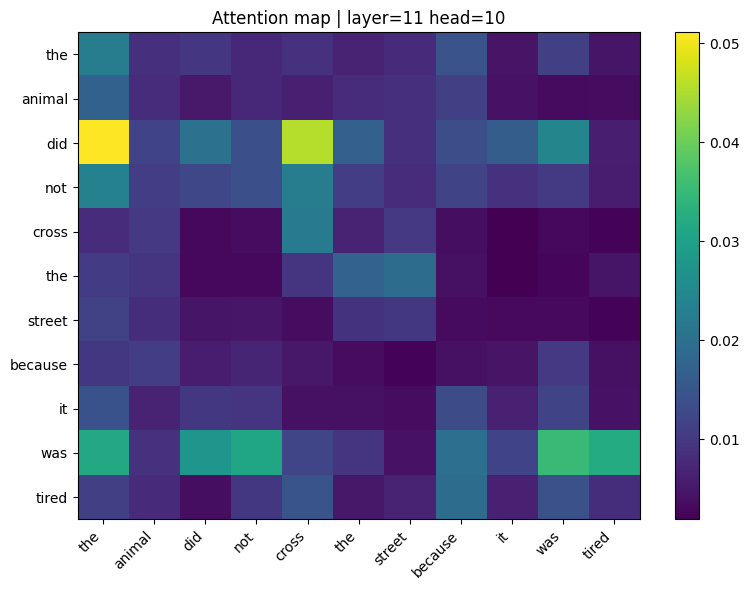

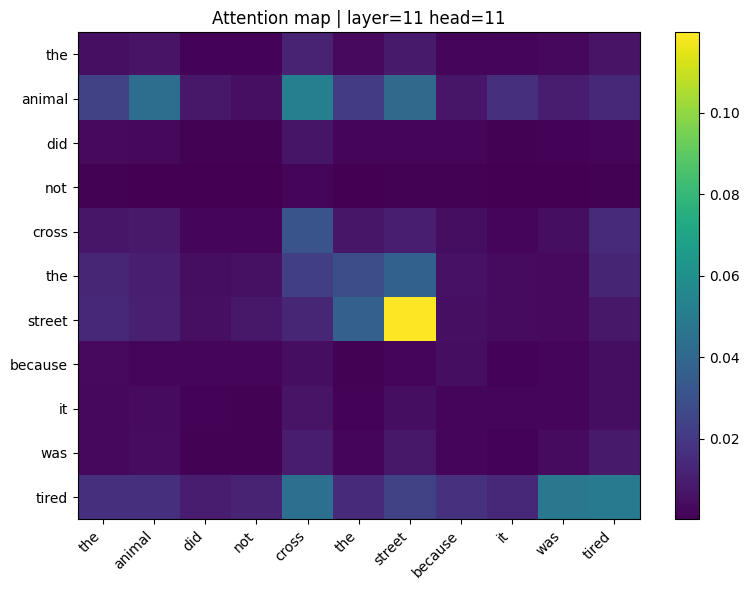

In [19]:
for layer in range(6,12):
    for head in range(12):
        plot_attention(
            tokenizer,
            model,
            "The animal did not cross the street because it was tired",
            layer=layer,
            head=head
        )

Busca la capa y head que capturan las relaciones de correferencia en las siguientes oraciones:

- En la siguiente oración "The trophy does not fit in the suitcase because it is too big", “it” se refiere a “the trophy” (el trofeo), no a la maleta.

- En la siguiente oración "The trophy does not fit in the suitcase because it is too small", “it” se refiere a  "the suitcase” (el trofeo), no al trofeo.

- The doctor called the patient because he was worried, ¿a quién se refiere it?

